In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

from toy_image_generator import get_toy_image_example_batch
from diffuser_ddpm_linear_schedule import Diffuser_DDPM_linear_schedule
from unet import DiffusionUNet
from unet_example_config import DiffuserConfig
#from unet_config import DiffuserConfig

# Setup

In [2]:
#Init
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

torch.manual_seed(0)
np.random.seed(0)

cuda


In [3]:
# Create scheduler model
ddpm_model = Diffuser_DDPM_linear_schedule(total_timesteps=1000, beta_start=0.0001, beta_end=0.02)

ddpm_model.betas = ddpm_model.betas.to(device)
ddpm_model.alphas = ddpm_model.alphas.to(device)
ddpm_model.alpha_bars = ddpm_model.alpha_bars.to(device)

In [4]:
# Create model
config = DiffuserConfig()
unet = DiffusionUNet(
    config=config,
    model_in_channels=3,
    model_out_channels=3
).to(device)

optimizer = torch.optim.AdamW(unet.parameters(), lr=2e-4, weight_decay=1e-5)

In [ ]:
# Dataloader
def make_toy_batch(batch_size=8, x_dim=64, y_dim=64):

    # Hue values are in [0, 180], so we pick a starting hue and sample all other values based on the batch size.
    start_hue_1s = np.random.randint(0, 180)
    hue_1_offsets = np.linspace(0, 180, num=batch_size, endpoint=False)
    hue_1s = (start_hue_1s + hue_1_offsets) % 180

    # Hue 2 is always the "opposite" hue, i.e. 90 degrees apart in the hue circle.
    hue_2s = (hue_1s + 90) % 180

    # Maximize saturation and value for the coloured regions so we focus on the hue only.
    saturation_1s = np.full(batch_size, 255)
    saturation_2s = np.full(batch_size, 255)
    value_1s = np.full(batch_size, 255)
    value_2s = np.full(batch_size, 255)
    
    # The line remains black, so the HSV values remain identical per batch.
    hue_3s = np.zeros(batch_size)
    saturation_3s = np.zeros(batch_size)
    value_3s = np.zeros(batch_size)

    # The angles are in [0, 360], so we pick a starting angle and sample all other angles based on the batch size.
    start_angle = np.random.rand() * 360
    angle_offsets = np.linspace(0, 360, num=batch_size, endpoint=False)
    angles = (start_angle + angle_offsets) % 360
    
    # Line width is randomly sampled between two values per image per batch.
    line_widths = np.random.randint(10, 20, size=batch_size)

    # Retrieve a batch of normalized images in CxHxW format based on the above parameters.
    batch = get_toy_image_example_batch(
        x_dim=x_dim,
        y_dim=y_dim,
        hue_1s=hue_1s,
        saturation_1s=saturation_1s,
        value_1s=value_1s,
        hue_2s=hue_2s,
        saturation_2s=saturation_2s,
        value_2s=value_2s,
        hue_3s=hue_3s,
        saturation_3s=saturation_3s,
        value_3s=value_3s,
        angles=angles,
        line_widths=line_widths,
    )
    return batch.to(device)

In [ ]:
def train_step(data, minibatch_size, model, ddpm):
    
    model.train()
    optimizer.zero_grad(set_to_none=True)

    # Number of iterations per training step equals the amount of minibatches needed to sample all data per training step.
    number_of_minibatches = data.shape[0] // minibatch_size
    total_loss = 0.0

    for i in range(number_of_minibatches):
        
        # Retrieve the data corresponding to the current minibatch.
        start_idx = i * minibatch_size
        end_idx = start_idx + minibatch_size
        data_minibatch = data[start_idx:end_idx]

        # Randomly sample diffusion timesteps for each data sample in the minibatch.
        B = data_minibatch.shape[0]
        t = torch.randint(0, ddpm.total_timesteps, (B,), device=device, dtype=torch.long).view(-1)

        # Perform a forward diffusion step to time t and retrieve the corresponding noisy sample x_t and the true added noise.
        x_t, true_noise = ddpm.forward_diffusion(data_minibatch, t)
        
        # Let the prediction model predict the added noise given the noisy sample x_t and the diffusion timestep t.
        pred_noise = model(x_t, t)
        
        # Compute the loss as the mean squared error and normalize based on the number of minibatches.
        loss = F.mse_loss(pred_noise, true_noise) / number_of_minibatches
        
        # Perform backward pass to compute gradient per minibatch.
        loss.backward()

        total_loss += loss.detach().item()
        
    # Perform an optimization step based on the accumulated gradients of all minibatches.
    optimizer.step()

    return total_loss

# Sampling

In [ ]:
@torch.no_grad()
def sample(model, ddpm, shape, fixed_noise=None):
    model.eval()

    x = torch.randn(shape, device=device)

    if fixed_noise != None:
        x = fixed_noise

    for t in range(ddpm.total_timesteps - 1, 0, -1):
        ts = torch.full((shape[0],), t, device=device, dtype=torch.long).view(-1)
        pred_noise = model(x, ts)
        x = ddpm.reverse_diffusion(x, ts, pred_noise)

    return x

In [8]:
def show_images(img_batch, title=None):
    img_batch = img_batch.detach().cpu()
    fig, axes = plt.subplots(1, img_batch.shape[0], figsize=(4 * img_batch.shape[0], 4))
    if img_batch.shape[0] == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        img = img_batch[i]
        img = (img + 1.0) / 2.0
        img = (img * 255.0).clamp(0, 255).byte()
        img = img.permute(1, 2, 0).numpy()
        ax.imshow(img)
        ax.axis("off")

    if title:
        fig.suptitle(title)
    plt.show()

# Run and Show

step     0 | loss 1.0881
step     1 | loss 0.9726
step     2 | loss 0.8761
step     3 | loss 0.7817
step     4 | loss 0.7200
step     5 | loss 0.6281
step     6 | loss 0.5712
step     7 | loss 0.5209
step     8 | loss 0.4634
step     9 | loss 0.4210
step    10 | loss 0.3920
step    11 | loss 0.3482
step    12 | loss 0.3266
step    13 | loss 0.3133
step    14 | loss 0.2861
step    15 | loss 0.2653
step    16 | loss 0.2412
step    17 | loss 0.2392
step    18 | loss 0.2199
step    19 | loss 0.2119
step    20 | loss 0.2027
step    21 | loss 0.1804
step    22 | loss 0.1883
step    23 | loss 0.1726
step    24 | loss 0.1727
step    25 | loss 0.1762
step    26 | loss 0.1569
step    27 | loss 0.1614
step    28 | loss 0.1505
step    29 | loss 0.1336
step    30 | loss 0.1506
step    31 | loss 0.1437
step    32 | loss 0.1395
step    33 | loss 0.1413
step    34 | loss 0.1343
step    35 | loss 0.1284
step    36 | loss 0.1228
step    37 | loss 0.1183
step    38 | loss 0.1211
step    39 | loss 0.1244


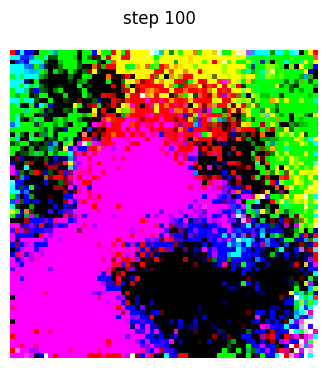

step   101 | loss 0.0694
step   102 | loss 0.0619
step   103 | loss 0.0649
step   104 | loss 0.0606
step   105 | loss 0.0659
step   106 | loss 0.0622
step   107 | loss 0.0639
step   108 | loss 0.0567
step   109 | loss 0.0570
step   110 | loss 0.0578
step   111 | loss 0.0598
step   112 | loss 0.0613
step   113 | loss 0.0564
step   114 | loss 0.0562
step   115 | loss 0.0576
step   116 | loss 0.0562
step   117 | loss 0.0582
step   118 | loss 0.0545
step   119 | loss 0.0566
step   120 | loss 0.0553
step   121 | loss 0.0576
step   122 | loss 0.0545
step   123 | loss 0.0541
step   124 | loss 0.0507
step   125 | loss 0.0551
step   126 | loss 0.0572
step   127 | loss 0.0575
step   128 | loss 0.0492
step   129 | loss 0.0576
step   130 | loss 0.0499
step   131 | loss 0.0503
step   132 | loss 0.0541
step   133 | loss 0.0499
step   134 | loss 0.0485
step   135 | loss 0.0486
step   136 | loss 0.0510
step   137 | loss 0.0489
step   138 | loss 0.0486
step   139 | loss 0.0489
step   140 | loss 0.0437


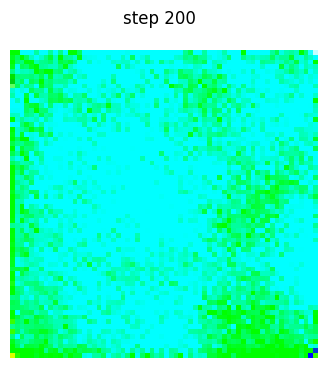

step   201 | loss 0.0427
step   202 | loss 0.0393
step   203 | loss 0.0341
step   204 | loss 0.0362
step   205 | loss 0.0346
step   206 | loss 0.0365
step   207 | loss 0.0374
step   208 | loss 0.0362
step   209 | loss 0.0355
step   210 | loss 0.0379
step   211 | loss 0.0349
step   212 | loss 0.0383
step   213 | loss 0.0317
step   214 | loss 0.0331
step   215 | loss 0.0369
step   216 | loss 0.0303
step   217 | loss 0.0339
step   218 | loss 0.0359
step   219 | loss 0.0299
step   220 | loss 0.0340
step   221 | loss 0.0287
step   222 | loss 0.0351
step   223 | loss 0.0377
step   224 | loss 0.0336
step   225 | loss 0.0345
step   226 | loss 0.0319
step   227 | loss 0.0309
step   228 | loss 0.0300
step   229 | loss 0.0312
step   230 | loss 0.0349
step   231 | loss 0.0316
step   232 | loss 0.0348
step   233 | loss 0.0352
step   234 | loss 0.0300
step   235 | loss 0.0315
step   236 | loss 0.0281
step   237 | loss 0.0294
step   238 | loss 0.0312
step   239 | loss 0.0270
step   240 | loss 0.0311


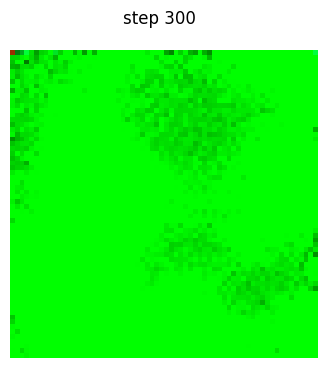

step   301 | loss 0.0264
step   302 | loss 0.0248
step   303 | loss 0.0266
step   304 | loss 0.0272
step   305 | loss 0.0243
step   306 | loss 0.0257
step   307 | loss 0.0252
step   308 | loss 0.0299
step   309 | loss 0.0254
step   310 | loss 0.0244
step   311 | loss 0.0214
step   312 | loss 0.0244
step   313 | loss 0.0279
step   314 | loss 0.0219
step   315 | loss 0.0277
step   316 | loss 0.0212
step   317 | loss 0.0251
step   318 | loss 0.0241
step   319 | loss 0.0276
step   320 | loss 0.0274
step   321 | loss 0.0210
step   322 | loss 0.0233
step   323 | loss 0.0228
step   324 | loss 0.0266
step   325 | loss 0.0254
step   326 | loss 0.0243
step   327 | loss 0.0259
step   328 | loss 0.0219
step   329 | loss 0.0219
step   330 | loss 0.0248
step   331 | loss 0.0254
step   332 | loss 0.0244
step   333 | loss 0.0269
step   334 | loss 0.0268
step   335 | loss 0.0252
step   336 | loss 0.0261
step   337 | loss 0.0236
step   338 | loss 0.0211
step   339 | loss 0.0228
step   340 | loss 0.0252


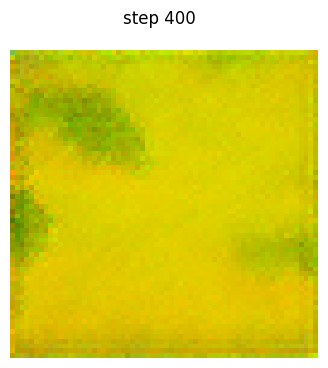

step   401 | loss 0.0201
step   402 | loss 0.0225
step   403 | loss 0.0227
step   404 | loss 0.0237
step   405 | loss 0.0198
step   406 | loss 0.0237
step   407 | loss 0.0217
step   408 | loss 0.0197
step   409 | loss 0.0177
step   410 | loss 0.0192
step   411 | loss 0.0167
step   412 | loss 0.0189
step   413 | loss 0.0202
step   414 | loss 0.0196
step   415 | loss 0.0213
step   416 | loss 0.0199
step   417 | loss 0.0228
step   418 | loss 0.0248
step   419 | loss 0.0165
step   420 | loss 0.0215
step   421 | loss 0.0205
step   422 | loss 0.0196
step   423 | loss 0.0226
step   424 | loss 0.0225
step   425 | loss 0.0211
step   426 | loss 0.0195
step   427 | loss 0.0219
step   428 | loss 0.0191
step   429 | loss 0.0209
step   430 | loss 0.0193
step   431 | loss 0.0212
step   432 | loss 0.0192
step   433 | loss 0.0203
step   434 | loss 0.0223
step   435 | loss 0.0184
step   436 | loss 0.0205
step   437 | loss 0.0214
step   438 | loss 0.0224
step   439 | loss 0.0197
step   440 | loss 0.0171


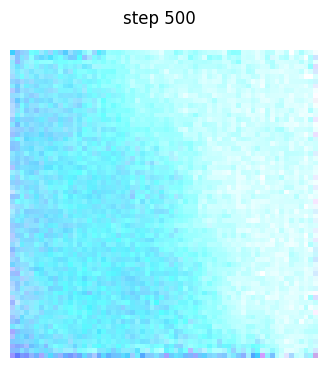

step   501 | loss 0.0174
step   502 | loss 0.0155
step   503 | loss 0.0193
step   504 | loss 0.0196
step   505 | loss 0.0178
step   506 | loss 0.0166
step   507 | loss 0.0202
step   508 | loss 0.0168
step   509 | loss 0.0171
step   510 | loss 0.0192
step   511 | loss 0.0169
step   512 | loss 0.0228
step   513 | loss 0.0196
step   514 | loss 0.0168
step   515 | loss 0.0185
step   516 | loss 0.0170
step   517 | loss 0.0182
step   518 | loss 0.0169
step   519 | loss 0.0163
step   520 | loss 0.0185
step   521 | loss 0.0186
step   522 | loss 0.0175
step   523 | loss 0.0178
step   524 | loss 0.0180
step   525 | loss 0.0156
step   526 | loss 0.0200
step   527 | loss 0.0160
step   528 | loss 0.0184
step   529 | loss 0.0147
step   530 | loss 0.0189
step   531 | loss 0.0177
step   532 | loss 0.0174
step   533 | loss 0.0172
step   534 | loss 0.0168
step   535 | loss 0.0202
step   536 | loss 0.0195
step   537 | loss 0.0180
step   538 | loss 0.0173
step   539 | loss 0.0196
step   540 | loss 0.0184


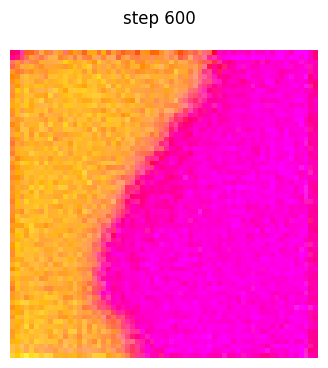

step   601 | loss 0.0164
step   602 | loss 0.0147
step   603 | loss 0.0152
step   604 | loss 0.0155
step   605 | loss 0.0130
step   606 | loss 0.0140
step   607 | loss 0.0176
step   608 | loss 0.0147
step   609 | loss 0.0160
step   610 | loss 0.0158
step   611 | loss 0.0174
step   612 | loss 0.0158
step   613 | loss 0.0150
step   614 | loss 0.0174
step   615 | loss 0.0154
step   616 | loss 0.0147
step   617 | loss 0.0138
step   618 | loss 0.0147
step   619 | loss 0.0169
step   620 | loss 0.0169
step   621 | loss 0.0125
step   622 | loss 0.0151
step   623 | loss 0.0161
step   624 | loss 0.0150
step   625 | loss 0.0155
step   626 | loss 0.0151
step   627 | loss 0.0174
step   628 | loss 0.0175
step   629 | loss 0.0175
step   630 | loss 0.0152
step   631 | loss 0.0172
step   632 | loss 0.0194
step   633 | loss 0.0147
step   634 | loss 0.0179
step   635 | loss 0.0169
step   636 | loss 0.0158
step   637 | loss 0.0131
step   638 | loss 0.0141
step   639 | loss 0.0173
step   640 | loss 0.0179


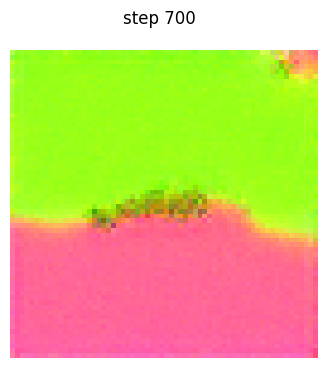

step   701 | loss 0.0133
step   702 | loss 0.0140
step   703 | loss 0.0157
step   704 | loss 0.0151
step   705 | loss 0.0128
step   706 | loss 0.0152
step   707 | loss 0.0140
step   708 | loss 0.0123
step   709 | loss 0.0177
step   710 | loss 0.0128
step   711 | loss 0.0140
step   712 | loss 0.0133
step   713 | loss 0.0133
step   714 | loss 0.0139
step   715 | loss 0.0157
step   716 | loss 0.0143
step   717 | loss 0.0124
step   718 | loss 0.0133
step   719 | loss 0.0151
step   720 | loss 0.0152
step   721 | loss 0.0144
step   722 | loss 0.0143
step   723 | loss 0.0143
step   724 | loss 0.0154
step   725 | loss 0.0123
step   726 | loss 0.0143
step   727 | loss 0.0139
step   728 | loss 0.0135
step   729 | loss 0.0158
step   730 | loss 0.0159
step   731 | loss 0.0147
step   732 | loss 0.0141
step   733 | loss 0.0154
step   734 | loss 0.0143
step   735 | loss 0.0131
step   736 | loss 0.0139
step   737 | loss 0.0125
step   738 | loss 0.0128
step   739 | loss 0.0139
step   740 | loss 0.0172


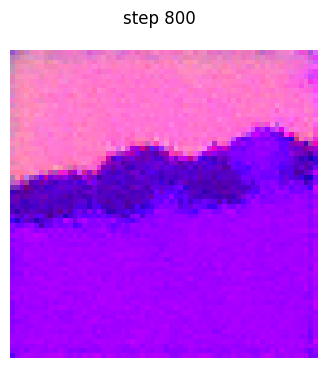

step   801 | loss 0.0145
step   802 | loss 0.0146
step   803 | loss 0.0142
step   804 | loss 0.0144
step   805 | loss 0.0158
step   806 | loss 0.0136
step   807 | loss 0.0156
step   808 | loss 0.0155
step   809 | loss 0.0137
step   810 | loss 0.0146
step   811 | loss 0.0134
step   812 | loss 0.0137
step   813 | loss 0.0144
step   814 | loss 0.0136
step   815 | loss 0.0147
step   816 | loss 0.0129
step   817 | loss 0.0126
step   818 | loss 0.0128
step   819 | loss 0.0129
step   820 | loss 0.0113
step   821 | loss 0.0140
step   822 | loss 0.0143
step   823 | loss 0.0152
step   824 | loss 0.0124
step   825 | loss 0.0130
step   826 | loss 0.0111
step   827 | loss 0.0133
step   828 | loss 0.0133
step   829 | loss 0.0136
step   830 | loss 0.0132
step   831 | loss 0.0114
step   832 | loss 0.0127
step   833 | loss 0.0117
step   834 | loss 0.0136
step   835 | loss 0.0120
step   836 | loss 0.0114
step   837 | loss 0.0137
step   838 | loss 0.0118
step   839 | loss 0.0117
step   840 | loss 0.0128


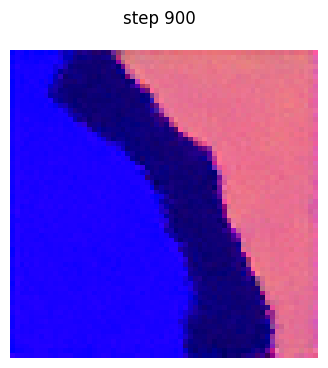

step   901 | loss 0.0092
step   902 | loss 0.0136
step   903 | loss 0.0122
step   904 | loss 0.0139
step   905 | loss 0.0128
step   906 | loss 0.0122
step   907 | loss 0.0112
step   908 | loss 0.0123
step   909 | loss 0.0129
step   910 | loss 0.0109
step   911 | loss 0.0123
step   912 | loss 0.0134
step   913 | loss 0.0122
step   914 | loss 0.0121
step   915 | loss 0.0114
step   916 | loss 0.0133
step   917 | loss 0.0143
step   918 | loss 0.0115
step   919 | loss 0.0132
step   920 | loss 0.0129
step   921 | loss 0.0140
step   922 | loss 0.0135
step   923 | loss 0.0135
step   924 | loss 0.0142
step   925 | loss 0.0137
step   926 | loss 0.0141
step   927 | loss 0.0117
step   928 | loss 0.0113
step   929 | loss 0.0126
step   930 | loss 0.0115
step   931 | loss 0.0131
step   932 | loss 0.0138
step   933 | loss 0.0152
step   934 | loss 0.0142
step   935 | loss 0.0119
step   936 | loss 0.0113
step   937 | loss 0.0106
step   938 | loss 0.0123
step   939 | loss 0.0130
step   940 | loss 0.0117


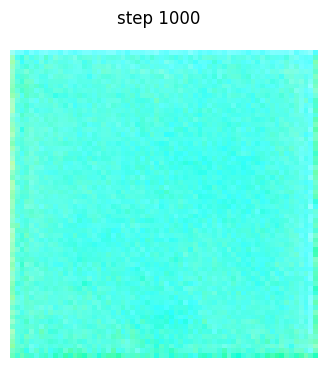

step  1001 | loss 0.0124
step  1002 | loss 0.0117
step  1003 | loss 0.0125
step  1004 | loss 0.0121
step  1005 | loss 0.0132
step  1006 | loss 0.0113
step  1007 | loss 0.0102
step  1008 | loss 0.0109
step  1009 | loss 0.0109
step  1010 | loss 0.0123
step  1011 | loss 0.0105
step  1012 | loss 0.0124
step  1013 | loss 0.0135
step  1014 | loss 0.0129
step  1015 | loss 0.0136
step  1016 | loss 0.0129
step  1017 | loss 0.0101
step  1018 | loss 0.0124
step  1019 | loss 0.0103
step  1020 | loss 0.0124
step  1021 | loss 0.0113
step  1022 | loss 0.0126
step  1023 | loss 0.0120
step  1024 | loss 0.0109
step  1025 | loss 0.0095
step  1026 | loss 0.0095
step  1027 | loss 0.0112
step  1028 | loss 0.0113
step  1029 | loss 0.0106
step  1030 | loss 0.0119
step  1031 | loss 0.0112
step  1032 | loss 0.0106
step  1033 | loss 0.0113
step  1034 | loss 0.0110
step  1035 | loss 0.0111
step  1036 | loss 0.0102
step  1037 | loss 0.0122
step  1038 | loss 0.0133
step  1039 | loss 0.0128
step  1040 | loss 0.0109


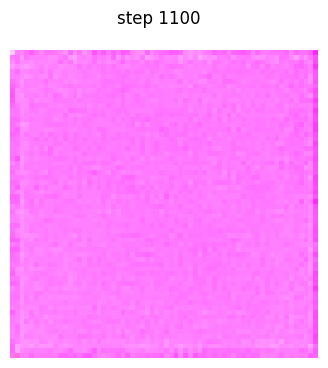

step  1101 | loss 0.0099
step  1102 | loss 0.0098
step  1103 | loss 0.0127
step  1104 | loss 0.0113
step  1105 | loss 0.0112
step  1106 | loss 0.0113
step  1107 | loss 0.0127
step  1108 | loss 0.0122
step  1109 | loss 0.0108
step  1110 | loss 0.0115
step  1111 | loss 0.0116
step  1112 | loss 0.0116
step  1113 | loss 0.0107
step  1114 | loss 0.0121
step  1115 | loss 0.0116
step  1116 | loss 0.0104
step  1117 | loss 0.0119
step  1118 | loss 0.0113
step  1119 | loss 0.0120
step  1120 | loss 0.0115
step  1121 | loss 0.0115
step  1122 | loss 0.0110
step  1123 | loss 0.0102
step  1124 | loss 0.0101
step  1125 | loss 0.0115
step  1126 | loss 0.0125
step  1127 | loss 0.0101
step  1128 | loss 0.0111
step  1129 | loss 0.0109
step  1130 | loss 0.0116
step  1131 | loss 0.0100
step  1132 | loss 0.0124
step  1133 | loss 0.0107
step  1134 | loss 0.0129
step  1135 | loss 0.0103
step  1136 | loss 0.0114
step  1137 | loss 0.0134
step  1138 | loss 0.0112
step  1139 | loss 0.0117
step  1140 | loss 0.0111


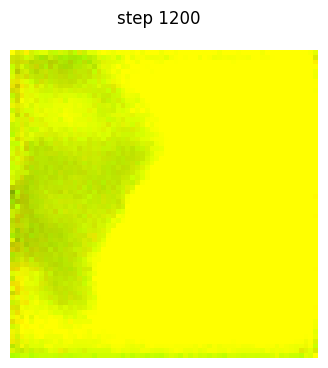

step  1201 | loss 0.0109
step  1202 | loss 0.0107
step  1203 | loss 0.0118
step  1204 | loss 0.0113
step  1205 | loss 0.0109
step  1206 | loss 0.0106
step  1207 | loss 0.0114
step  1208 | loss 0.0105
step  1209 | loss 0.0108
step  1210 | loss 0.0104
step  1211 | loss 0.0108
step  1212 | loss 0.0098
step  1213 | loss 0.0116
step  1214 | loss 0.0100
step  1215 | loss 0.0087
step  1216 | loss 0.0125
step  1217 | loss 0.0114
step  1218 | loss 0.0096
step  1219 | loss 0.0105
step  1220 | loss 0.0114
step  1221 | loss 0.0111
step  1222 | loss 0.0106
step  1223 | loss 0.0089
step  1224 | loss 0.0107
step  1225 | loss 0.0114
step  1226 | loss 0.0102
step  1227 | loss 0.0108
step  1228 | loss 0.0098
step  1229 | loss 0.0109
step  1230 | loss 0.0099
step  1231 | loss 0.0112
step  1232 | loss 0.0126
step  1233 | loss 0.0105
step  1234 | loss 0.0105
step  1235 | loss 0.0125
step  1236 | loss 0.0100
step  1237 | loss 0.0103
step  1238 | loss 0.0110
step  1239 | loss 0.0107
step  1240 | loss 0.0109


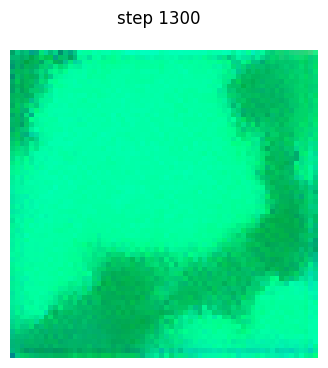

step  1301 | loss 0.0136
step  1302 | loss 0.0118
step  1303 | loss 0.0133
step  1304 | loss 0.0116
step  1305 | loss 0.0143
step  1306 | loss 0.0116
step  1307 | loss 0.0131
step  1308 | loss 0.0108
step  1309 | loss 0.0121
step  1310 | loss 0.0116
step  1311 | loss 0.0116
step  1312 | loss 0.0110
step  1313 | loss 0.0113
step  1314 | loss 0.0110
step  1315 | loss 0.0122
step  1316 | loss 0.0086
step  1317 | loss 0.0112
step  1318 | loss 0.0089
step  1319 | loss 0.0104
step  1320 | loss 0.0099
step  1321 | loss 0.0104
step  1322 | loss 0.0096
step  1323 | loss 0.0107
step  1324 | loss 0.0111
step  1325 | loss 0.0108
step  1326 | loss 0.0115
step  1327 | loss 0.0103
step  1328 | loss 0.0110
step  1329 | loss 0.0087
step  1330 | loss 0.0095
step  1331 | loss 0.0118
step  1332 | loss 0.0097
step  1333 | loss 0.0089
step  1334 | loss 0.0095
step  1335 | loss 0.0097
step  1336 | loss 0.0091
step  1337 | loss 0.0104
step  1338 | loss 0.0090
step  1339 | loss 0.0095
step  1340 | loss 0.0097


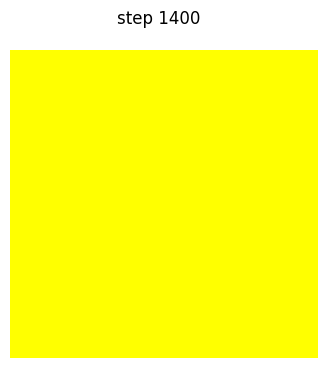

step  1401 | loss 0.0105
step  1402 | loss 0.0107
step  1403 | loss 0.0108
step  1404 | loss 0.0102
step  1405 | loss 0.0103
step  1406 | loss 0.0091
step  1407 | loss 0.0098
step  1408 | loss 0.0085
step  1409 | loss 0.0094
step  1410 | loss 0.0104
step  1411 | loss 0.0091
step  1412 | loss 0.0094
step  1413 | loss 0.0095
step  1414 | loss 0.0087
step  1415 | loss 0.0106
step  1416 | loss 0.0083
step  1417 | loss 0.0099
step  1418 | loss 0.0100
step  1419 | loss 0.0101
step  1420 | loss 0.0070
step  1421 | loss 0.0099
step  1422 | loss 0.0080
step  1423 | loss 0.0102
step  1424 | loss 0.0088
step  1425 | loss 0.0107
step  1426 | loss 0.0097
step  1427 | loss 0.0085
step  1428 | loss 0.0084
step  1429 | loss 0.0091
step  1430 | loss 0.0084
step  1431 | loss 0.0087
step  1432 | loss 0.0103
step  1433 | loss 0.0082
step  1434 | loss 0.0093
step  1435 | loss 0.0084
step  1436 | loss 0.0096
step  1437 | loss 0.0075
step  1438 | loss 0.0089
step  1439 | loss 0.0088
step  1440 | loss 0.0093


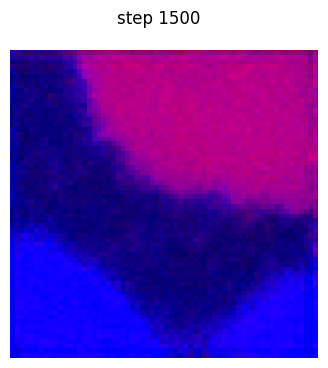

step  1501 | loss 0.0084
step  1502 | loss 0.0097
step  1503 | loss 0.0095
step  1504 | loss 0.0091
step  1505 | loss 0.0081
step  1506 | loss 0.0079
step  1507 | loss 0.0098
step  1508 | loss 0.0095
step  1509 | loss 0.0092
step  1510 | loss 0.0091
step  1511 | loss 0.0088
step  1512 | loss 0.0092
step  1513 | loss 0.0092
step  1514 | loss 0.0084
step  1515 | loss 0.0099
step  1516 | loss 0.0085
step  1517 | loss 0.0087
step  1518 | loss 0.0086
step  1519 | loss 0.0097
step  1520 | loss 0.0095
step  1521 | loss 0.0075
step  1522 | loss 0.0092
step  1523 | loss 0.0093
step  1524 | loss 0.0089
step  1525 | loss 0.0074
step  1526 | loss 0.0079
step  1527 | loss 0.0088
step  1528 | loss 0.0101
step  1529 | loss 0.0102
step  1530 | loss 0.0086
step  1531 | loss 0.0082
step  1532 | loss 0.0083
step  1533 | loss 0.0083
step  1534 | loss 0.0090
step  1535 | loss 0.0086
step  1536 | loss 0.0098
step  1537 | loss 0.0096
step  1538 | loss 0.0076
step  1539 | loss 0.0095
step  1540 | loss 0.0098


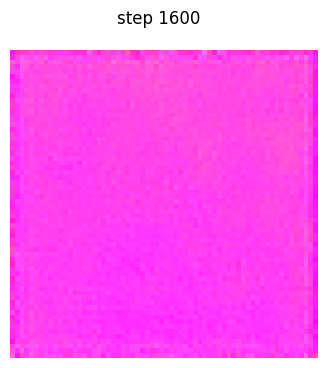

step  1601 | loss 0.0092
step  1602 | loss 0.0113
step  1603 | loss 0.0096
step  1604 | loss 0.0092
step  1605 | loss 0.0092
step  1606 | loss 0.0093
step  1607 | loss 0.0087
step  1608 | loss 0.0093
step  1609 | loss 0.0093
step  1610 | loss 0.0087
step  1611 | loss 0.0091
step  1612 | loss 0.0078
step  1613 | loss 0.0075
step  1614 | loss 0.0088
step  1615 | loss 0.0085
step  1616 | loss 0.0095
step  1617 | loss 0.0086
step  1618 | loss 0.0103
step  1619 | loss 0.0085
step  1620 | loss 0.0086
step  1621 | loss 0.0095
step  1622 | loss 0.0094
step  1623 | loss 0.0092
step  1624 | loss 0.0089
step  1625 | loss 0.0074
step  1626 | loss 0.0089
step  1627 | loss 0.0095
step  1628 | loss 0.0097
step  1629 | loss 0.0080
step  1630 | loss 0.0083
step  1631 | loss 0.0083
step  1632 | loss 0.0083
step  1633 | loss 0.0088
step  1634 | loss 0.0086
step  1635 | loss 0.0087
step  1636 | loss 0.0086
step  1637 | loss 0.0086
step  1638 | loss 0.0087
step  1639 | loss 0.0093
step  1640 | loss 0.0084


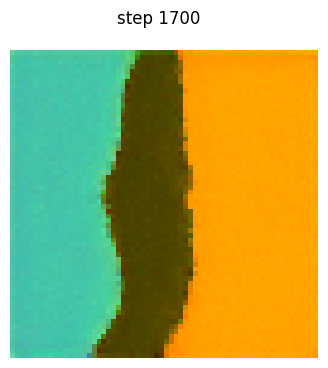

step  1701 | loss 0.0071
step  1702 | loss 0.0094
step  1703 | loss 0.0075
step  1704 | loss 0.0088
step  1705 | loss 0.0097
step  1706 | loss 0.0084
step  1707 | loss 0.0086
step  1708 | loss 0.0092
step  1709 | loss 0.0087
step  1710 | loss 0.0095
step  1711 | loss 0.0080
step  1712 | loss 0.0094
step  1713 | loss 0.0090
step  1714 | loss 0.0084
step  1715 | loss 0.0103
step  1716 | loss 0.0089
step  1717 | loss 0.0096
step  1718 | loss 0.0084
step  1719 | loss 0.0091
step  1720 | loss 0.0090
step  1721 | loss 0.0137
step  1722 | loss 0.0088
step  1723 | loss 0.0111
step  1724 | loss 0.0109
step  1725 | loss 0.0099
step  1726 | loss 0.0118
step  1727 | loss 0.0110
step  1728 | loss 0.0106
step  1729 | loss 0.0114
step  1730 | loss 0.0112
step  1731 | loss 0.0107
step  1732 | loss 0.0104
step  1733 | loss 0.0109
step  1734 | loss 0.0091
step  1735 | loss 0.0089
step  1736 | loss 0.0115
step  1737 | loss 0.0096
step  1738 | loss 0.0112
step  1739 | loss 0.0082
step  1740 | loss 0.0101


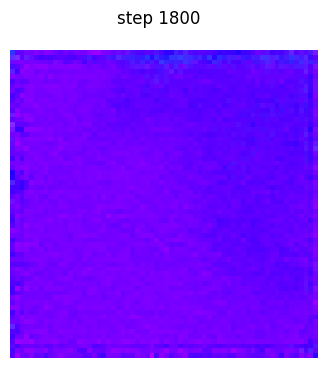

step  1801 | loss 0.0081
step  1802 | loss 0.0071
step  1803 | loss 0.0072
step  1804 | loss 0.0073
step  1805 | loss 0.0069
step  1806 | loss 0.0076
step  1807 | loss 0.0090
step  1808 | loss 0.0083
step  1809 | loss 0.0077
step  1810 | loss 0.0086
step  1811 | loss 0.0069
step  1812 | loss 0.0076
step  1813 | loss 0.0087
step  1814 | loss 0.0071
step  1815 | loss 0.0089
step  1816 | loss 0.0078
step  1817 | loss 0.0089
step  1818 | loss 0.0088
step  1819 | loss 0.0079
step  1820 | loss 0.0079
step  1821 | loss 0.0088
step  1822 | loss 0.0076
step  1823 | loss 0.0075
step  1824 | loss 0.0096
step  1825 | loss 0.0074
step  1826 | loss 0.0090
step  1827 | loss 0.0075
step  1828 | loss 0.0094
step  1829 | loss 0.0103
step  1830 | loss 0.0092
step  1831 | loss 0.0096
step  1832 | loss 0.0083
step  1833 | loss 0.0093
step  1834 | loss 0.0080
step  1835 | loss 0.0082
step  1836 | loss 0.0090
step  1837 | loss 0.0079
step  1838 | loss 0.0088
step  1839 | loss 0.0106
step  1840 | loss 0.0098


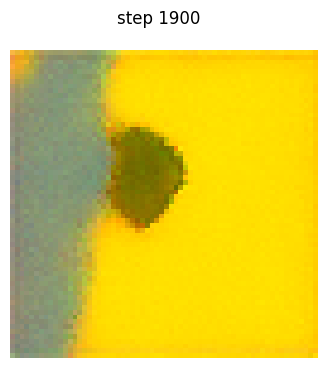

step  1901 | loss 0.0081
step  1902 | loss 0.0086
step  1903 | loss 0.0082
step  1904 | loss 0.0077
step  1905 | loss 0.0088
step  1906 | loss 0.0083
step  1907 | loss 0.0074
step  1908 | loss 0.0093
step  1909 | loss 0.0089
step  1910 | loss 0.0078
step  1911 | loss 0.0081
step  1912 | loss 0.0090
step  1913 | loss 0.0079
step  1914 | loss 0.0084
step  1915 | loss 0.0089
step  1916 | loss 0.0101
step  1917 | loss 0.0074
step  1918 | loss 0.0110
step  1919 | loss 0.0084
step  1920 | loss 0.0083
step  1921 | loss 0.0093
step  1922 | loss 0.0075
step  1923 | loss 0.0083
step  1924 | loss 0.0071
step  1925 | loss 0.0103
step  1926 | loss 0.0089
step  1927 | loss 0.0084
step  1928 | loss 0.0078
step  1929 | loss 0.0094
step  1930 | loss 0.0082
step  1931 | loss 0.0080
step  1932 | loss 0.0082
step  1933 | loss 0.0083
step  1934 | loss 0.0072
step  1935 | loss 0.0081
step  1936 | loss 0.0073
step  1937 | loss 0.0103
step  1938 | loss 0.0079
step  1939 | loss 0.0075
step  1940 | loss 0.0077


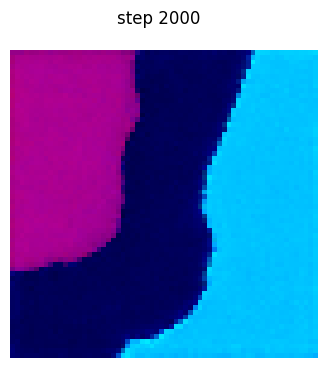

step  2001 | loss 0.0080
step  2002 | loss 0.0069
step  2003 | loss 0.0069
step  2004 | loss 0.0080
step  2005 | loss 0.0064
step  2006 | loss 0.0084
step  2007 | loss 0.0082
step  2008 | loss 0.0076
step  2009 | loss 0.0078
step  2010 | loss 0.0076
step  2011 | loss 0.0073
step  2012 | loss 0.0086
step  2013 | loss 0.0081
step  2014 | loss 0.0071
step  2015 | loss 0.0080
step  2016 | loss 0.0072
step  2017 | loss 0.0080
step  2018 | loss 0.0085
step  2019 | loss 0.0071
step  2020 | loss 0.0073
step  2021 | loss 0.0071
step  2022 | loss 0.0077
step  2023 | loss 0.0074
step  2024 | loss 0.0078
step  2025 | loss 0.0092
step  2026 | loss 0.0076
step  2027 | loss 0.0077
step  2028 | loss 0.0081
step  2029 | loss 0.0070
step  2030 | loss 0.0087
step  2031 | loss 0.0083
step  2032 | loss 0.0090
step  2033 | loss 0.0073
step  2034 | loss 0.0072
step  2035 | loss 0.0072
step  2036 | loss 0.0071
step  2037 | loss 0.0081
step  2038 | loss 0.0069
step  2039 | loss 0.0083
step  2040 | loss 0.0085


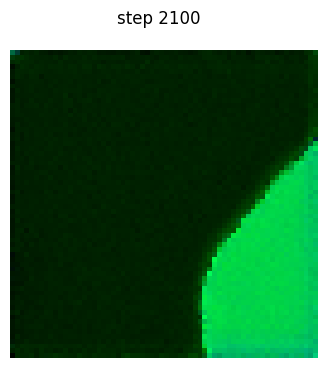

step  2101 | loss 0.0071
step  2102 | loss 0.0084
step  2103 | loss 0.0068
step  2104 | loss 0.0064
step  2105 | loss 0.0092
step  2106 | loss 0.0075
step  2107 | loss 0.0097
step  2108 | loss 0.0068
step  2109 | loss 0.0082
step  2110 | loss 0.0068
step  2111 | loss 0.0089
step  2112 | loss 0.0072
step  2113 | loss 0.0070
step  2114 | loss 0.0077
step  2115 | loss 0.0084
step  2116 | loss 0.0080
step  2117 | loss 0.0071
step  2118 | loss 0.0081
step  2119 | loss 0.0079
step  2120 | loss 0.0069
step  2121 | loss 0.0080
step  2122 | loss 0.0071
step  2123 | loss 0.0064
step  2124 | loss 0.0067
step  2125 | loss 0.0066
step  2126 | loss 0.0065
step  2127 | loss 0.0068
step  2128 | loss 0.0078
step  2129 | loss 0.0076
step  2130 | loss 0.0069
step  2131 | loss 0.0065
step  2132 | loss 0.0071
step  2133 | loss 0.0079
step  2134 | loss 0.0079
step  2135 | loss 0.0069
step  2136 | loss 0.0090
step  2137 | loss 0.0069
step  2138 | loss 0.0075
step  2139 | loss 0.0067
step  2140 | loss 0.0069


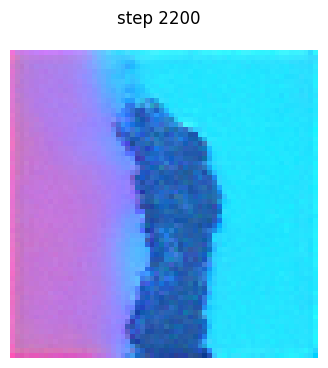

step  2201 | loss 0.0082
step  2202 | loss 0.0098
step  2203 | loss 0.0081
step  2204 | loss 0.0079
step  2205 | loss 0.0093
step  2206 | loss 0.0081
step  2207 | loss 0.0078
step  2208 | loss 0.0065
step  2209 | loss 0.0086
step  2210 | loss 0.0087
step  2211 | loss 0.0081
step  2212 | loss 0.0102
step  2213 | loss 0.0094
step  2214 | loss 0.0078
step  2215 | loss 0.0093
step  2216 | loss 0.0087
step  2217 | loss 0.0078
step  2218 | loss 0.0073
step  2219 | loss 0.0083
step  2220 | loss 0.0089
step  2221 | loss 0.0076
step  2222 | loss 0.0068
step  2223 | loss 0.0075
step  2224 | loss 0.0079
step  2225 | loss 0.0074
step  2226 | loss 0.0079
step  2227 | loss 0.0093
step  2228 | loss 0.0075
step  2229 | loss 0.0066
step  2230 | loss 0.0068
step  2231 | loss 0.0082
step  2232 | loss 0.0070
step  2233 | loss 0.0062
step  2234 | loss 0.0076
step  2235 | loss 0.0069
step  2236 | loss 0.0059
step  2237 | loss 0.0062
step  2238 | loss 0.0062
step  2239 | loss 0.0057
step  2240 | loss 0.0066


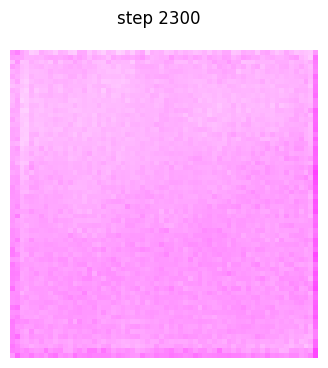

step  2301 | loss 0.0072
step  2302 | loss 0.0062
step  2303 | loss 0.0071
step  2304 | loss 0.0063
step  2305 | loss 0.0067
step  2306 | loss 0.0068
step  2307 | loss 0.0081
step  2308 | loss 0.0064
step  2309 | loss 0.0070
step  2310 | loss 0.0067
step  2311 | loss 0.0083
step  2312 | loss 0.0073
step  2313 | loss 0.0066
step  2314 | loss 0.0054
step  2315 | loss 0.0084
step  2316 | loss 0.0061
step  2317 | loss 0.0065
step  2318 | loss 0.0076
step  2319 | loss 0.0063
step  2320 | loss 0.0058
step  2321 | loss 0.0070
step  2322 | loss 0.0062
step  2323 | loss 0.0061
step  2324 | loss 0.0075
step  2325 | loss 0.0072
step  2326 | loss 0.0066
step  2327 | loss 0.0067
step  2328 | loss 0.0067
step  2329 | loss 0.0060
step  2330 | loss 0.0070
step  2331 | loss 0.0071
step  2332 | loss 0.0068
step  2333 | loss 0.0067
step  2334 | loss 0.0071
step  2335 | loss 0.0073
step  2336 | loss 0.0056
step  2337 | loss 0.0067
step  2338 | loss 0.0065
step  2339 | loss 0.0066
step  2340 | loss 0.0066


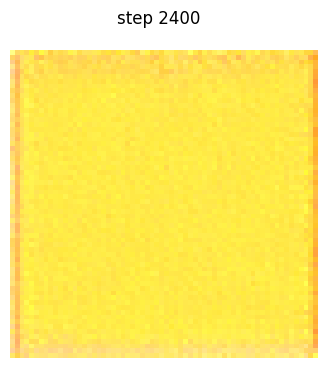

step  2401 | loss 0.0071
step  2402 | loss 0.0059
step  2403 | loss 0.0059
step  2404 | loss 0.0069
step  2405 | loss 0.0064
step  2406 | loss 0.0064
step  2407 | loss 0.0052
step  2408 | loss 0.0057
step  2409 | loss 0.0064
step  2410 | loss 0.0064
step  2411 | loss 0.0063
step  2412 | loss 0.0056
step  2413 | loss 0.0066
step  2414 | loss 0.0065
step  2415 | loss 0.0069
step  2416 | loss 0.0051
step  2417 | loss 0.0067
step  2418 | loss 0.0061
step  2419 | loss 0.0066
step  2420 | loss 0.0065
step  2421 | loss 0.0083
step  2422 | loss 0.0071
step  2423 | loss 0.0065
step  2424 | loss 0.0067
step  2425 | loss 0.0062
step  2426 | loss 0.0065
step  2427 | loss 0.0063
step  2428 | loss 0.0065
step  2429 | loss 0.0074
step  2430 | loss 0.0063
step  2431 | loss 0.0069
step  2432 | loss 0.0082
step  2433 | loss 0.0073
step  2434 | loss 0.0075
step  2435 | loss 0.0077
step  2436 | loss 0.0070
step  2437 | loss 0.0065
step  2438 | loss 0.0072
step  2439 | loss 0.0061
step  2440 | loss 0.0092


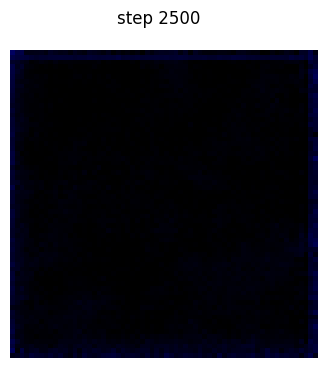

step  2501 | loss 0.0076
step  2502 | loss 0.0074
step  2503 | loss 0.0061
step  2504 | loss 0.0066
step  2505 | loss 0.0060
step  2506 | loss 0.0068
step  2507 | loss 0.0067
step  2508 | loss 0.0060
step  2509 | loss 0.0059
step  2510 | loss 0.0068
step  2511 | loss 0.0060
step  2512 | loss 0.0060
step  2513 | loss 0.0063
step  2514 | loss 0.0062
step  2515 | loss 0.0064
step  2516 | loss 0.0065
step  2517 | loss 0.0063
step  2518 | loss 0.0058
step  2519 | loss 0.0063
step  2520 | loss 0.0057
step  2521 | loss 0.0058
step  2522 | loss 0.0074
step  2523 | loss 0.0059
step  2524 | loss 0.0063
step  2525 | loss 0.0060
step  2526 | loss 0.0062
step  2527 | loss 0.0064
step  2528 | loss 0.0058
step  2529 | loss 0.0063
step  2530 | loss 0.0060
step  2531 | loss 0.0060
step  2532 | loss 0.0054
step  2533 | loss 0.0062
step  2534 | loss 0.0063
step  2535 | loss 0.0053
step  2536 | loss 0.0060
step  2537 | loss 0.0057
step  2538 | loss 0.0059
step  2539 | loss 0.0064
step  2540 | loss 0.0059


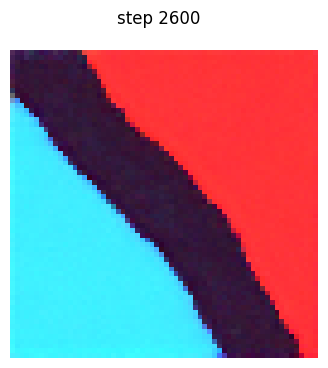

step  2601 | loss 0.0063
step  2602 | loss 0.0064
step  2603 | loss 0.0079
step  2604 | loss 0.0062
step  2605 | loss 0.0059
step  2606 | loss 0.0063
step  2607 | loss 0.0060
step  2608 | loss 0.0071
step  2609 | loss 0.0064
step  2610 | loss 0.0081
step  2611 | loss 0.0058
step  2612 | loss 0.0060
step  2613 | loss 0.0062
step  2614 | loss 0.0059
step  2615 | loss 0.0075
step  2616 | loss 0.0065
step  2617 | loss 0.0063
step  2618 | loss 0.0070
step  2619 | loss 0.0071
step  2620 | loss 0.0059
step  2621 | loss 0.0071
step  2622 | loss 0.0061
step  2623 | loss 0.0055
step  2624 | loss 0.0073
step  2625 | loss 0.0068
step  2626 | loss 0.0075
step  2627 | loss 0.0086
step  2628 | loss 0.0088
step  2629 | loss 0.0073
step  2630 | loss 0.0099
step  2631 | loss 0.0078
step  2632 | loss 0.0081
step  2633 | loss 0.0075
step  2634 | loss 0.0074
step  2635 | loss 0.0071
step  2636 | loss 0.0080
step  2637 | loss 0.0074
step  2638 | loss 0.0076
step  2639 | loss 0.0067
step  2640 | loss 0.0066


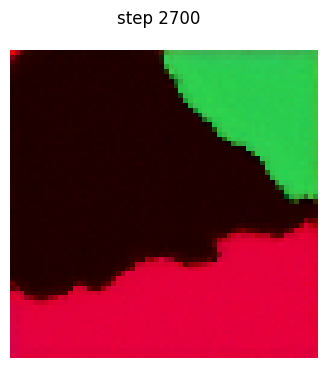

step  2701 | loss 0.0065
step  2702 | loss 0.0060
step  2703 | loss 0.0064
step  2704 | loss 0.0057
step  2705 | loss 0.0062
step  2706 | loss 0.0060
step  2707 | loss 0.0061
step  2708 | loss 0.0061
step  2709 | loss 0.0062
step  2710 | loss 0.0059
step  2711 | loss 0.0052
step  2712 | loss 0.0059
step  2713 | loss 0.0064
step  2714 | loss 0.0056
step  2715 | loss 0.0066
step  2716 | loss 0.0054
step  2717 | loss 0.0056
step  2718 | loss 0.0050
step  2719 | loss 0.0055
step  2720 | loss 0.0048
step  2721 | loss 0.0059
step  2722 | loss 0.0055
step  2723 | loss 0.0055
step  2724 | loss 0.0059
step  2725 | loss 0.0052
step  2726 | loss 0.0068
step  2727 | loss 0.0052
step  2728 | loss 0.0052
step  2729 | loss 0.0062
step  2730 | loss 0.0058
step  2731 | loss 0.0056
step  2732 | loss 0.0061
step  2733 | loss 0.0053
step  2734 | loss 0.0061
step  2735 | loss 0.0055
step  2736 | loss 0.0063
step  2737 | loss 0.0058
step  2738 | loss 0.0064
step  2739 | loss 0.0060
step  2740 | loss 0.0070


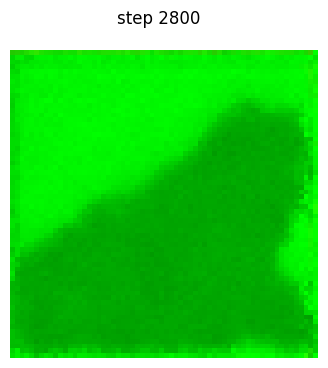

step  2801 | loss 0.0071
step  2802 | loss 0.0057
step  2803 | loss 0.0059
step  2804 | loss 0.0058
step  2805 | loss 0.0055
step  2806 | loss 0.0054
step  2807 | loss 0.0066
step  2808 | loss 0.0064
step  2809 | loss 0.0067
step  2810 | loss 0.0068
step  2811 | loss 0.0070
step  2812 | loss 0.0071
step  2813 | loss 0.0054
step  2814 | loss 0.0063
step  2815 | loss 0.0063
step  2816 | loss 0.0067
step  2817 | loss 0.0070
step  2818 | loss 0.0062
step  2819 | loss 0.0073
step  2820 | loss 0.0071
step  2821 | loss 0.0060
step  2822 | loss 0.0072
step  2823 | loss 0.0060
step  2824 | loss 0.0064
step  2825 | loss 0.0083
step  2826 | loss 0.0063
step  2827 | loss 0.0073
step  2828 | loss 0.0071
step  2829 | loss 0.0071
step  2830 | loss 0.0064
step  2831 | loss 0.0072
step  2832 | loss 0.0070
step  2833 | loss 0.0060
step  2834 | loss 0.0069
step  2835 | loss 0.0068
step  2836 | loss 0.0065
step  2837 | loss 0.0065
step  2838 | loss 0.0063
step  2839 | loss 0.0061
step  2840 | loss 0.0064


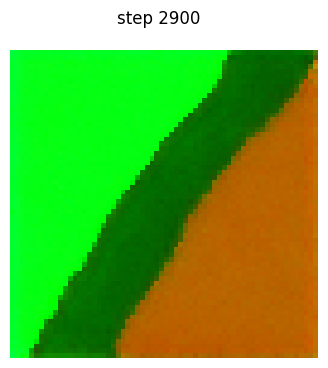

step  2901 | loss 0.0061
step  2902 | loss 0.0050
step  2903 | loss 0.0055
step  2904 | loss 0.0052
step  2905 | loss 0.0056
step  2906 | loss 0.0067
step  2907 | loss 0.0059
step  2908 | loss 0.0053
step  2909 | loss 0.0052
step  2910 | loss 0.0053
step  2911 | loss 0.0058
step  2912 | loss 0.0062
step  2913 | loss 0.0052
step  2914 | loss 0.0057
step  2915 | loss 0.0049
step  2916 | loss 0.0047
step  2917 | loss 0.0060
step  2918 | loss 0.0045
step  2919 | loss 0.0061
step  2920 | loss 0.0054
step  2921 | loss 0.0049
step  2922 | loss 0.0057
step  2923 | loss 0.0050
step  2924 | loss 0.0048
step  2925 | loss 0.0046
step  2926 | loss 0.0053
step  2927 | loss 0.0045
step  2928 | loss 0.0054
step  2929 | loss 0.0047
step  2930 | loss 0.0055
step  2931 | loss 0.0048
step  2932 | loss 0.0056
step  2933 | loss 0.0051
step  2934 | loss 0.0048
step  2935 | loss 0.0055
step  2936 | loss 0.0050
step  2937 | loss 0.0051
step  2938 | loss 0.0048
step  2939 | loss 0.0058
step  2940 | loss 0.0059


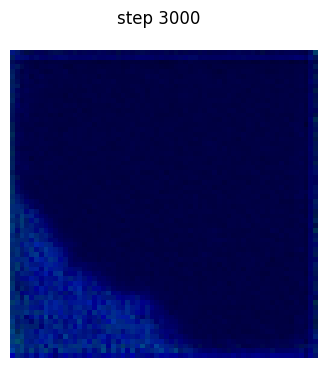

step  3001 | loss 0.0055
step  3002 | loss 0.0059
step  3003 | loss 0.0056
step  3004 | loss 0.0053
step  3005 | loss 0.0055
step  3006 | loss 0.0050
step  3007 | loss 0.0053
step  3008 | loss 0.0050
step  3009 | loss 0.0054
step  3010 | loss 0.0053
step  3011 | loss 0.0053
step  3012 | loss 0.0054
step  3013 | loss 0.0054
step  3014 | loss 0.0054
step  3015 | loss 0.0054
step  3016 | loss 0.0059
step  3017 | loss 0.0049
step  3018 | loss 0.0050
step  3019 | loss 0.0057
step  3020 | loss 0.0054
step  3021 | loss 0.0051
step  3022 | loss 0.0056
step  3023 | loss 0.0057
step  3024 | loss 0.0047
step  3025 | loss 0.0058
step  3026 | loss 0.0051
step  3027 | loss 0.0056
step  3028 | loss 0.0054
step  3029 | loss 0.0064
step  3030 | loss 0.0052
step  3031 | loss 0.0047
step  3032 | loss 0.0049
step  3033 | loss 0.0046
step  3034 | loss 0.0055
step  3035 | loss 0.0050
step  3036 | loss 0.0071
step  3037 | loss 0.0061
step  3038 | loss 0.0050
step  3039 | loss 0.0054
step  3040 | loss 0.0051


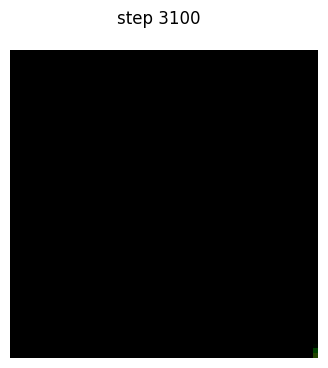

step  3101 | loss 0.0061
step  3102 | loss 0.0062
step  3103 | loss 0.0061
step  3104 | loss 0.0050
step  3105 | loss 0.0068
step  3106 | loss 0.0049
step  3107 | loss 0.0050
step  3108 | loss 0.0060
step  3109 | loss 0.0058
step  3110 | loss 0.0062
step  3111 | loss 0.0054
step  3112 | loss 0.0046
step  3113 | loss 0.0058
step  3114 | loss 0.0058
step  3115 | loss 0.0055
step  3116 | loss 0.0060
step  3117 | loss 0.0057
step  3118 | loss 0.0065
step  3119 | loss 0.0084
step  3120 | loss 0.0059
step  3121 | loss 0.0063
step  3122 | loss 0.0051
step  3123 | loss 0.0065
step  3124 | loss 0.0053
step  3125 | loss 0.0053
step  3126 | loss 0.0050
step  3127 | loss 0.0055
step  3128 | loss 0.0054
step  3129 | loss 0.0062
step  3130 | loss 0.0049
step  3131 | loss 0.0058
step  3132 | loss 0.0052
step  3133 | loss 0.0056
step  3134 | loss 0.0060
step  3135 | loss 0.0052
step  3136 | loss 0.0056
step  3137 | loss 0.0054
step  3138 | loss 0.0052
step  3139 | loss 0.0048
step  3140 | loss 0.0060


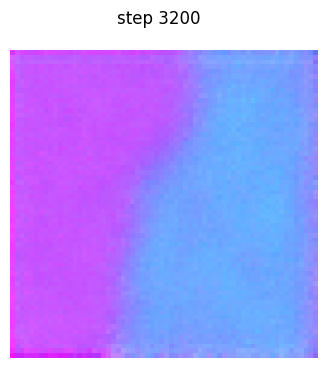

step  3201 | loss 0.0048
step  3202 | loss 0.0052
step  3203 | loss 0.0048
step  3204 | loss 0.0059
step  3205 | loss 0.0052
step  3206 | loss 0.0046
step  3207 | loss 0.0054
step  3208 | loss 0.0044
step  3209 | loss 0.0046
step  3210 | loss 0.0059
step  3211 | loss 0.0053
step  3212 | loss 0.0047
step  3213 | loss 0.0054
step  3214 | loss 0.0049
step  3215 | loss 0.0052
step  3216 | loss 0.0052
step  3217 | loss 0.0050
step  3218 | loss 0.0053
step  3219 | loss 0.0044
step  3220 | loss 0.0046
step  3221 | loss 0.0057
step  3222 | loss 0.0054
step  3223 | loss 0.0051
step  3224 | loss 0.0046
step  3225 | loss 0.0057
step  3226 | loss 0.0047
step  3227 | loss 0.0054
step  3228 | loss 0.0061
step  3229 | loss 0.0051
step  3230 | loss 0.0053
step  3231 | loss 0.0054
step  3232 | loss 0.0059
step  3233 | loss 0.0059
step  3234 | loss 0.0054
step  3235 | loss 0.0052
step  3236 | loss 0.0044
step  3237 | loss 0.0059
step  3238 | loss 0.0060
step  3239 | loss 0.0065
step  3240 | loss 0.0046


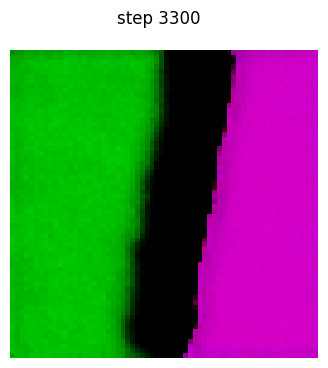

step  3301 | loss 0.0059
step  3302 | loss 0.0064
step  3303 | loss 0.0062
step  3304 | loss 0.0072
step  3305 | loss 0.0064
step  3306 | loss 0.0064
step  3307 | loss 0.0067
step  3308 | loss 0.0063
step  3309 | loss 0.0057
step  3310 | loss 0.0050
step  3311 | loss 0.0058
step  3312 | loss 0.0079
step  3313 | loss 0.0065
step  3314 | loss 0.0058
step  3315 | loss 0.0072
step  3316 | loss 0.0072
step  3317 | loss 0.0064
step  3318 | loss 0.0064
step  3319 | loss 0.0080
step  3320 | loss 0.0064
step  3321 | loss 0.0074
step  3322 | loss 0.0077
step  3323 | loss 0.0079
step  3324 | loss 0.0069
step  3325 | loss 0.0067
step  3326 | loss 0.0076
step  3327 | loss 0.0067
step  3328 | loss 0.0062
step  3329 | loss 0.0072
step  3330 | loss 0.0069
step  3331 | loss 0.0065
step  3332 | loss 0.0059
step  3333 | loss 0.0075
step  3334 | loss 0.0073
step  3335 | loss 0.0065
step  3336 | loss 0.0061
step  3337 | loss 0.0051
step  3338 | loss 0.0059
step  3339 | loss 0.0059
step  3340 | loss 0.0058


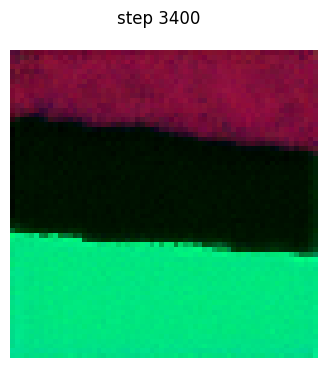

step  3401 | loss 0.0052
step  3402 | loss 0.0052
step  3403 | loss 0.0042
step  3404 | loss 0.0048
step  3405 | loss 0.0046
step  3406 | loss 0.0048
step  3407 | loss 0.0059
step  3408 | loss 0.0050
step  3409 | loss 0.0053
step  3410 | loss 0.0046
step  3411 | loss 0.0050
step  3412 | loss 0.0044
step  3413 | loss 0.0050
step  3414 | loss 0.0049
step  3415 | loss 0.0044
step  3416 | loss 0.0047
step  3417 | loss 0.0052
step  3418 | loss 0.0041
step  3419 | loss 0.0042
step  3420 | loss 0.0041
step  3421 | loss 0.0049
step  3422 | loss 0.0048
step  3423 | loss 0.0040
step  3424 | loss 0.0047
step  3425 | loss 0.0050
step  3426 | loss 0.0042
step  3427 | loss 0.0044
step  3428 | loss 0.0048
step  3429 | loss 0.0049
step  3430 | loss 0.0045
step  3431 | loss 0.0053
step  3432 | loss 0.0043
step  3433 | loss 0.0045
step  3434 | loss 0.0051
step  3435 | loss 0.0043
step  3436 | loss 0.0057
step  3437 | loss 0.0048
step  3438 | loss 0.0049
step  3439 | loss 0.0044
step  3440 | loss 0.0044


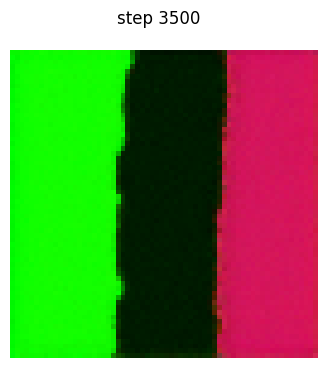

step  3501 | loss 0.0059
step  3502 | loss 0.0056
step  3503 | loss 0.0057
step  3504 | loss 0.0062
step  3505 | loss 0.0050
step  3506 | loss 0.0052
step  3507 | loss 0.0046
step  3508 | loss 0.0052
step  3509 | loss 0.0051
step  3510 | loss 0.0049
step  3511 | loss 0.0050
step  3512 | loss 0.0047
step  3513 | loss 0.0047
step  3514 | loss 0.0047
step  3515 | loss 0.0048
step  3516 | loss 0.0051
step  3517 | loss 0.0045
step  3518 | loss 0.0044
step  3519 | loss 0.0055
step  3520 | loss 0.0042
step  3521 | loss 0.0043
step  3522 | loss 0.0052
step  3523 | loss 0.0049
step  3524 | loss 0.0049
step  3525 | loss 0.0050
step  3526 | loss 0.0045
step  3527 | loss 0.0054
step  3528 | loss 0.0047
step  3529 | loss 0.0042
step  3530 | loss 0.0047
step  3531 | loss 0.0053
step  3532 | loss 0.0039
step  3533 | loss 0.0050
step  3534 | loss 0.0058
step  3535 | loss 0.0040
step  3536 | loss 0.0045
step  3537 | loss 0.0047
step  3538 | loss 0.0047
step  3539 | loss 0.0041
step  3540 | loss 0.0047


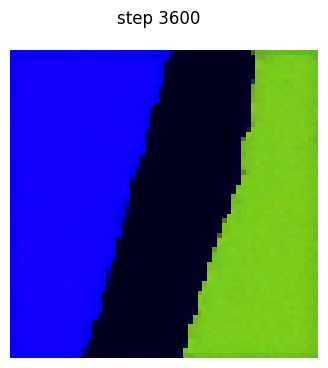

step  3601 | loss 0.0046
step  3602 | loss 0.0049
step  3603 | loss 0.0071
step  3604 | loss 0.0057
step  3605 | loss 0.0057
step  3606 | loss 0.0050
step  3607 | loss 0.0047
step  3608 | loss 0.0056
step  3609 | loss 0.0046
step  3610 | loss 0.0059
step  3611 | loss 0.0042
step  3612 | loss 0.0072
step  3613 | loss 0.0055
step  3614 | loss 0.0057
step  3615 | loss 0.0051
step  3616 | loss 0.0049
step  3617 | loss 0.0058
step  3618 | loss 0.0064
step  3619 | loss 0.0054
step  3620 | loss 0.0056
step  3621 | loss 0.0048
step  3622 | loss 0.0050
step  3623 | loss 0.0045
step  3624 | loss 0.0052
step  3625 | loss 0.0044
step  3626 | loss 0.0044
step  3627 | loss 0.0043
step  3628 | loss 0.0052
step  3629 | loss 0.0045
step  3630 | loss 0.0047
step  3631 | loss 0.0046
step  3632 | loss 0.0057
step  3633 | loss 0.0042
step  3634 | loss 0.0048
step  3635 | loss 0.0056
step  3636 | loss 0.0053
step  3637 | loss 0.0039
step  3638 | loss 0.0047
step  3639 | loss 0.0051
step  3640 | loss 0.0044


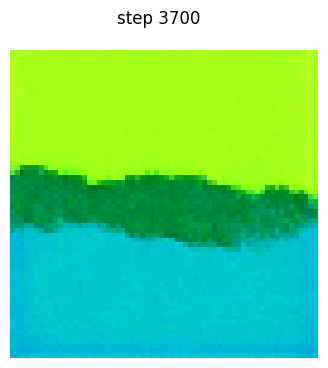

step  3701 | loss 0.0055
step  3702 | loss 0.0083
step  3703 | loss 0.0074
step  3704 | loss 0.0054
step  3705 | loss 0.0052
step  3706 | loss 0.0059
step  3707 | loss 0.0066
step  3708 | loss 0.0060
step  3709 | loss 0.0058
step  3710 | loss 0.0062
step  3711 | loss 0.0055
step  3712 | loss 0.0075
step  3713 | loss 0.0067
step  3714 | loss 0.0048
step  3715 | loss 0.0064
step  3716 | loss 0.0053
step  3717 | loss 0.0060
step  3718 | loss 0.0065
step  3719 | loss 0.0047
step  3720 | loss 0.0052
step  3721 | loss 0.0043
step  3722 | loss 0.0069
step  3723 | loss 0.0048
step  3724 | loss 0.0056
step  3725 | loss 0.0056
step  3726 | loss 0.0043
step  3727 | loss 0.0056
step  3728 | loss 0.0057
step  3729 | loss 0.0058
step  3730 | loss 0.0041
step  3731 | loss 0.0055
step  3732 | loss 0.0060
step  3733 | loss 0.0060
step  3734 | loss 0.0047
step  3735 | loss 0.0056
step  3736 | loss 0.0044
step  3737 | loss 0.0065
step  3738 | loss 0.0046
step  3739 | loss 0.0043
step  3740 | loss 0.0050


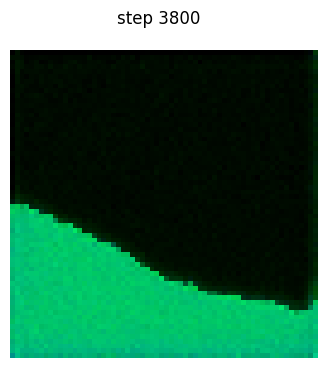

step  3801 | loss 0.0041
step  3802 | loss 0.0047
step  3803 | loss 0.0048
step  3804 | loss 0.0042
step  3805 | loss 0.0050
step  3806 | loss 0.0043
step  3807 | loss 0.0038
step  3808 | loss 0.0057
step  3809 | loss 0.0049
step  3810 | loss 0.0051
step  3811 | loss 0.0050
step  3812 | loss 0.0042
step  3813 | loss 0.0043
step  3814 | loss 0.0042
step  3815 | loss 0.0046
step  3816 | loss 0.0042
step  3817 | loss 0.0043
step  3818 | loss 0.0043
step  3819 | loss 0.0038
step  3820 | loss 0.0038
step  3821 | loss 0.0044
step  3822 | loss 0.0040
step  3823 | loss 0.0045
step  3824 | loss 0.0047
step  3825 | loss 0.0045
step  3826 | loss 0.0040
step  3827 | loss 0.0045
step  3828 | loss 0.0036
step  3829 | loss 0.0043
step  3830 | loss 0.0041
step  3831 | loss 0.0047
step  3832 | loss 0.0044
step  3833 | loss 0.0054
step  3834 | loss 0.0053
step  3835 | loss 0.0047
step  3836 | loss 0.0037
step  3837 | loss 0.0041
step  3838 | loss 0.0037
step  3839 | loss 0.0053
step  3840 | loss 0.0044


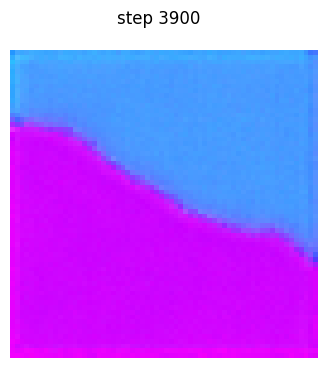

step  3901 | loss 0.0051
step  3902 | loss 0.0046
step  3903 | loss 0.0057
step  3904 | loss 0.0053
step  3905 | loss 0.0053
step  3906 | loss 0.0051
step  3907 | loss 0.0046
step  3908 | loss 0.0047
step  3909 | loss 0.0044
step  3910 | loss 0.0042
step  3911 | loss 0.0047
step  3912 | loss 0.0068
step  3913 | loss 0.0055
step  3914 | loss 0.0065
step  3915 | loss 0.0056
step  3916 | loss 0.0046
step  3917 | loss 0.0057
step  3918 | loss 0.0054
step  3919 | loss 0.0062
step  3920 | loss 0.0072
step  3921 | loss 0.0052
step  3922 | loss 0.0056
step  3923 | loss 0.0062
step  3924 | loss 0.0046
step  3925 | loss 0.0051
step  3926 | loss 0.0058
step  3927 | loss 0.0069
step  3928 | loss 0.0052
step  3929 | loss 0.0053
step  3930 | loss 0.0046
step  3931 | loss 0.0057
step  3932 | loss 0.0048
step  3933 | loss 0.0051
step  3934 | loss 0.0059
step  3935 | loss 0.0050
step  3936 | loss 0.0050
step  3937 | loss 0.0051
step  3938 | loss 0.0058
step  3939 | loss 0.0056
step  3940 | loss 0.0053


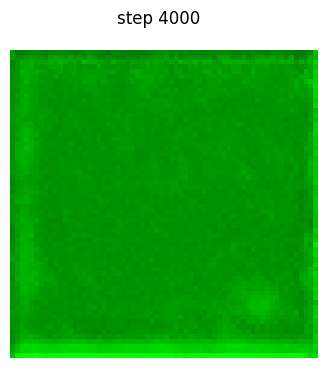

step  4001 | loss 0.0055
step  4002 | loss 0.0038
step  4003 | loss 0.0043
step  4004 | loss 0.0045
step  4005 | loss 0.0036
step  4006 | loss 0.0045
step  4007 | loss 0.0039
step  4008 | loss 0.0041
step  4009 | loss 0.0040
step  4010 | loss 0.0048
step  4011 | loss 0.0038
step  4012 | loss 0.0042
step  4013 | loss 0.0042
step  4014 | loss 0.0053
step  4015 | loss 0.0049
step  4016 | loss 0.0043
step  4017 | loss 0.0039
step  4018 | loss 0.0049
step  4019 | loss 0.0043
step  4020 | loss 0.0051
step  4021 | loss 0.0048
step  4022 | loss 0.0050
step  4023 | loss 0.0050
step  4024 | loss 0.0042
step  4025 | loss 0.0047
step  4026 | loss 0.0043
step  4027 | loss 0.0045
step  4028 | loss 0.0045
step  4029 | loss 0.0046
step  4030 | loss 0.0042
step  4031 | loss 0.0045
step  4032 | loss 0.0045
step  4033 | loss 0.0043
step  4034 | loss 0.0047
step  4035 | loss 0.0050
step  4036 | loss 0.0041
step  4037 | loss 0.0038
step  4038 | loss 0.0045
step  4039 | loss 0.0045
step  4040 | loss 0.0045


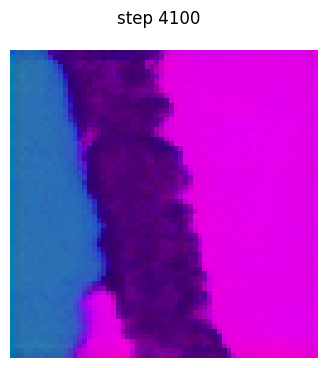

step  4101 | loss 0.0046
step  4102 | loss 0.0037
step  4103 | loss 0.0043
step  4104 | loss 0.0041
step  4105 | loss 0.0044
step  4106 | loss 0.0047
step  4107 | loss 0.0040
step  4108 | loss 0.0050
step  4109 | loss 0.0045
step  4110 | loss 0.0042
step  4111 | loss 0.0048
step  4112 | loss 0.0042
step  4113 | loss 0.0046
step  4114 | loss 0.0040
step  4115 | loss 0.0052
step  4116 | loss 0.0054
step  4117 | loss 0.0039
step  4118 | loss 0.0049
step  4119 | loss 0.0052
step  4120 | loss 0.0039
step  4121 | loss 0.0042
step  4122 | loss 0.0048
step  4123 | loss 0.0041
step  4124 | loss 0.0051
step  4125 | loss 0.0043
step  4126 | loss 0.0040
step  4127 | loss 0.0040
step  4128 | loss 0.0038
step  4129 | loss 0.0039
step  4130 | loss 0.0040
step  4131 | loss 0.0051
step  4132 | loss 0.0035
step  4133 | loss 0.0052
step  4134 | loss 0.0044
step  4135 | loss 0.0042
step  4136 | loss 0.0042
step  4137 | loss 0.0045
step  4138 | loss 0.0041
step  4139 | loss 0.0049
step  4140 | loss 0.0042


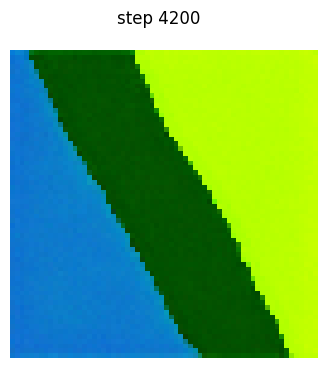

step  4201 | loss 0.0040
step  4202 | loss 0.0041
step  4203 | loss 0.0040
step  4204 | loss 0.0045
step  4205 | loss 0.0042
step  4206 | loss 0.0045
step  4207 | loss 0.0044
step  4208 | loss 0.0037
step  4209 | loss 0.0045
step  4210 | loss 0.0041
step  4211 | loss 0.0043
step  4212 | loss 0.0042
step  4213 | loss 0.0037
step  4214 | loss 0.0045
step  4215 | loss 0.0037
step  4216 | loss 0.0039
step  4217 | loss 0.0043
step  4218 | loss 0.0033
step  4219 | loss 0.0043
step  4220 | loss 0.0036
step  4221 | loss 0.0040
step  4222 | loss 0.0040
step  4223 | loss 0.0034
step  4224 | loss 0.0035
step  4225 | loss 0.0031
step  4226 | loss 0.0036
step  4227 | loss 0.0042
step  4228 | loss 0.0048
step  4229 | loss 0.0037
step  4230 | loss 0.0045
step  4231 | loss 0.0038
step  4232 | loss 0.0043
step  4233 | loss 0.0040
step  4234 | loss 0.0042
step  4235 | loss 0.0047
step  4236 | loss 0.0051
step  4237 | loss 0.0043
step  4238 | loss 0.0039
step  4239 | loss 0.0047
step  4240 | loss 0.0043


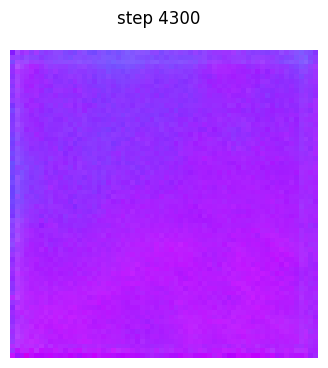

step  4301 | loss 0.0041
step  4302 | loss 0.0039
step  4303 | loss 0.0040
step  4304 | loss 0.0039
step  4305 | loss 0.0047
step  4306 | loss 0.0037
step  4307 | loss 0.0049
step  4308 | loss 0.0044
step  4309 | loss 0.0039
step  4310 | loss 0.0041
step  4311 | loss 0.0047
step  4312 | loss 0.0052
step  4313 | loss 0.0040
step  4314 | loss 0.0041
step  4315 | loss 0.0038
step  4316 | loss 0.0037
step  4317 | loss 0.0063
step  4318 | loss 0.0063
step  4319 | loss 0.0050
step  4320 | loss 0.0044
step  4321 | loss 0.0061
step  4322 | loss 0.0055
step  4323 | loss 0.0071
step  4324 | loss 0.0053
step  4325 | loss 0.0050
step  4326 | loss 0.0053
step  4327 | loss 0.0052
step  4328 | loss 0.0044
step  4329 | loss 0.0049
step  4330 | loss 0.0048
step  4331 | loss 0.0056
step  4332 | loss 0.0046
step  4333 | loss 0.0041
step  4334 | loss 0.0055
step  4335 | loss 0.0049
step  4336 | loss 0.0048
step  4337 | loss 0.0039
step  4338 | loss 0.0040
step  4339 | loss 0.0045
step  4340 | loss 0.0064


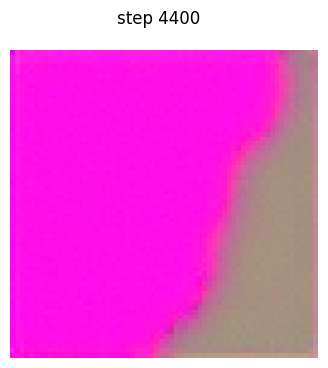

step  4401 | loss 0.0048
step  4402 | loss 0.0041
step  4403 | loss 0.0040
step  4404 | loss 0.0047
step  4405 | loss 0.0039
step  4406 | loss 0.0039
step  4407 | loss 0.0037
step  4408 | loss 0.0039
step  4409 | loss 0.0034
step  4410 | loss 0.0041
step  4411 | loss 0.0039
step  4412 | loss 0.0037
step  4413 | loss 0.0040
step  4414 | loss 0.0038
step  4415 | loss 0.0035
step  4416 | loss 0.0034
step  4417 | loss 0.0036
step  4418 | loss 0.0044
step  4419 | loss 0.0041
step  4420 | loss 0.0032
step  4421 | loss 0.0038
step  4422 | loss 0.0040
step  4423 | loss 0.0044
step  4424 | loss 0.0041
step  4425 | loss 0.0040
step  4426 | loss 0.0038
step  4427 | loss 0.0031
step  4428 | loss 0.0036
step  4429 | loss 0.0040
step  4430 | loss 0.0034
step  4431 | loss 0.0043
step  4432 | loss 0.0038
step  4433 | loss 0.0036
step  4434 | loss 0.0037
step  4435 | loss 0.0034
step  4436 | loss 0.0040
step  4437 | loss 0.0044
step  4438 | loss 0.0041
step  4439 | loss 0.0034
step  4440 | loss 0.0037


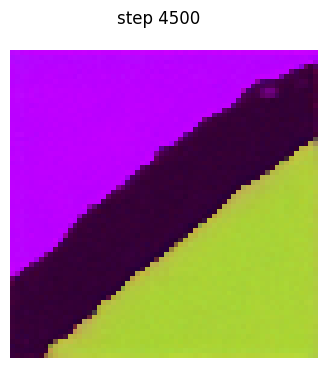

step  4501 | loss 0.0033
step  4502 | loss 0.0037
step  4503 | loss 0.0043
step  4504 | loss 0.0039
step  4505 | loss 0.0043
step  4506 | loss 0.0036
step  4507 | loss 0.0045
step  4508 | loss 0.0041
step  4509 | loss 0.0037
step  4510 | loss 0.0036
step  4511 | loss 0.0043
step  4512 | loss 0.0045
step  4513 | loss 0.0042
step  4514 | loss 0.0034
step  4515 | loss 0.0038
step  4516 | loss 0.0046
step  4517 | loss 0.0048
step  4518 | loss 0.0035
step  4519 | loss 0.0043
step  4520 | loss 0.0033
step  4521 | loss 0.0037
step  4522 | loss 0.0041
step  4523 | loss 0.0046
step  4524 | loss 0.0040
step  4525 | loss 0.0043
step  4526 | loss 0.0038
step  4527 | loss 0.0043
step  4528 | loss 0.0043
step  4529 | loss 0.0039
step  4530 | loss 0.0042
step  4531 | loss 0.0040
step  4532 | loss 0.0041
step  4533 | loss 0.0036
step  4534 | loss 0.0041
step  4535 | loss 0.0035
step  4536 | loss 0.0042
step  4537 | loss 0.0036
step  4538 | loss 0.0038
step  4539 | loss 0.0037
step  4540 | loss 0.0035


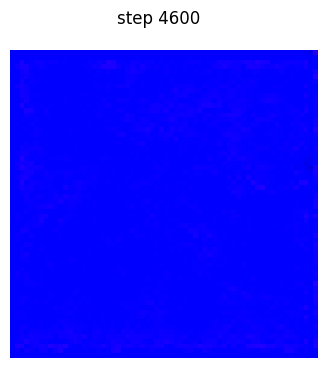

step  4601 | loss 0.0040
step  4602 | loss 0.0041
step  4603 | loss 0.0040
step  4604 | loss 0.0037
step  4605 | loss 0.0039
step  4606 | loss 0.0037
step  4607 | loss 0.0041
step  4608 | loss 0.0040
step  4609 | loss 0.0034
step  4610 | loss 0.0040
step  4611 | loss 0.0034
step  4612 | loss 0.0043
step  4613 | loss 0.0039
step  4614 | loss 0.0034
step  4615 | loss 0.0044
step  4616 | loss 0.0047
step  4617 | loss 0.0035
step  4618 | loss 0.0034
step  4619 | loss 0.0038
step  4620 | loss 0.0039
step  4621 | loss 0.0036
step  4622 | loss 0.0030
step  4623 | loss 0.0038
step  4624 | loss 0.0033
step  4625 | loss 0.0034
step  4626 | loss 0.0031
step  4627 | loss 0.0044
step  4628 | loss 0.0031
step  4629 | loss 0.0040
step  4630 | loss 0.0037
step  4631 | loss 0.0041
step  4632 | loss 0.0039
step  4633 | loss 0.0038
step  4634 | loss 0.0037
step  4635 | loss 0.0039
step  4636 | loss 0.0037
step  4637 | loss 0.0045
step  4638 | loss 0.0045
step  4639 | loss 0.0068
step  4640 | loss 0.0053


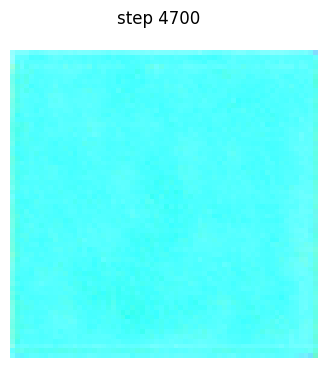

step  4701 | loss 0.0033
step  4702 | loss 0.0034
step  4703 | loss 0.0049
step  4704 | loss 0.0040
step  4705 | loss 0.0039
step  4706 | loss 0.0043
step  4707 | loss 0.0037
step  4708 | loss 0.0044
step  4709 | loss 0.0032
step  4710 | loss 0.0047
step  4711 | loss 0.0042
step  4712 | loss 0.0062
step  4713 | loss 0.0041
step  4714 | loss 0.0049
step  4715 | loss 0.0047
step  4716 | loss 0.0043
step  4717 | loss 0.0047
step  4718 | loss 0.0050
step  4719 | loss 0.0043
step  4720 | loss 0.0051
step  4721 | loss 0.0045
step  4722 | loss 0.0046
step  4723 | loss 0.0042
step  4724 | loss 0.0038
step  4725 | loss 0.0037
step  4726 | loss 0.0039
step  4727 | loss 0.0041
step  4728 | loss 0.0048
step  4729 | loss 0.0045
step  4730 | loss 0.0036
step  4731 | loss 0.0038
step  4732 | loss 0.0031
step  4733 | loss 0.0034
step  4734 | loss 0.0043
step  4735 | loss 0.0033
step  4736 | loss 0.0040
step  4737 | loss 0.0033
step  4738 | loss 0.0039
step  4739 | loss 0.0036
step  4740 | loss 0.0038


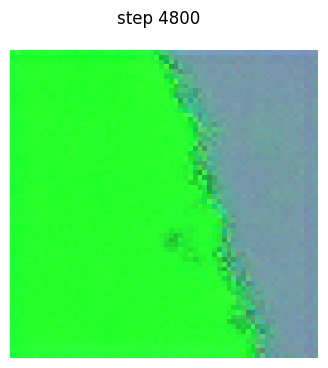

step  4801 | loss 0.0032
step  4802 | loss 0.0033
step  4803 | loss 0.0034
step  4804 | loss 0.0036
step  4805 | loss 0.0039
step  4806 | loss 0.0048
step  4807 | loss 0.0037
step  4808 | loss 0.0036
step  4809 | loss 0.0044
step  4810 | loss 0.0050
step  4811 | loss 0.0044
step  4812 | loss 0.0039
step  4813 | loss 0.0038
step  4814 | loss 0.0040
step  4815 | loss 0.0038
step  4816 | loss 0.0035
step  4817 | loss 0.0042
step  4818 | loss 0.0044
step  4819 | loss 0.0045
step  4820 | loss 0.0041
step  4821 | loss 0.0040
step  4822 | loss 0.0046
step  4823 | loss 0.0036
step  4824 | loss 0.0035
step  4825 | loss 0.0043
step  4826 | loss 0.0037
step  4827 | loss 0.0040
step  4828 | loss 0.0044
step  4829 | loss 0.0042
step  4830 | loss 0.0041
step  4831 | loss 0.0034
step  4832 | loss 0.0037
step  4833 | loss 0.0033
step  4834 | loss 0.0038
step  4835 | loss 0.0040
step  4836 | loss 0.0034
step  4837 | loss 0.0047
step  4838 | loss 0.0038
step  4839 | loss 0.0041
step  4840 | loss 0.0046


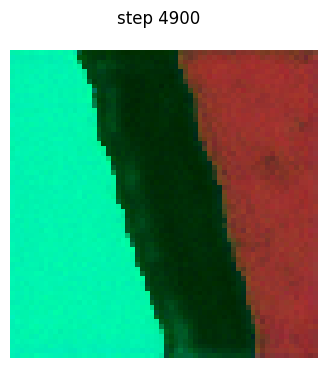

step  4901 | loss 0.0032
step  4902 | loss 0.0046
step  4903 | loss 0.0039
step  4904 | loss 0.0037
step  4905 | loss 0.0045
step  4906 | loss 0.0038
step  4907 | loss 0.0034
step  4908 | loss 0.0055
step  4909 | loss 0.0052
step  4910 | loss 0.0046
step  4911 | loss 0.0040
step  4912 | loss 0.0048
step  4913 | loss 0.0063
step  4914 | loss 0.0050
step  4915 | loss 0.0066
step  4916 | loss 0.0063
step  4917 | loss 0.0068
step  4918 | loss 0.0059
step  4919 | loss 0.0056
step  4920 | loss 0.0052
step  4921 | loss 0.0056
step  4922 | loss 0.0050
step  4923 | loss 0.0043
step  4924 | loss 0.0060
step  4925 | loss 0.0051
step  4926 | loss 0.0052
step  4927 | loss 0.0044
step  4928 | loss 0.0041
step  4929 | loss 0.0038
step  4930 | loss 0.0049
step  4931 | loss 0.0050
step  4932 | loss 0.0045
step  4933 | loss 0.0042
step  4934 | loss 0.0041
step  4935 | loss 0.0048
step  4936 | loss 0.0044
step  4937 | loss 0.0039
step  4938 | loss 0.0048
step  4939 | loss 0.0039
step  4940 | loss 0.0044


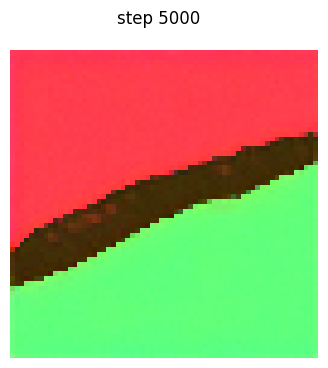

step  5001 | loss 0.0043
step  5002 | loss 0.0037
step  5003 | loss 0.0052
step  5004 | loss 0.0048
step  5005 | loss 0.0038
step  5006 | loss 0.0033
step  5007 | loss 0.0039
step  5008 | loss 0.0052
step  5009 | loss 0.0046
step  5010 | loss 0.0042
step  5011 | loss 0.0039
step  5012 | loss 0.0037
step  5013 | loss 0.0035
step  5014 | loss 0.0056
step  5015 | loss 0.0040
step  5016 | loss 0.0045
step  5017 | loss 0.0043
step  5018 | loss 0.0042
step  5019 | loss 0.0051
step  5020 | loss 0.0042
step  5021 | loss 0.0038
step  5022 | loss 0.0038
step  5023 | loss 0.0040
step  5024 | loss 0.0040
step  5025 | loss 0.0048
step  5026 | loss 0.0037
step  5027 | loss 0.0043
step  5028 | loss 0.0031
step  5029 | loss 0.0031
step  5030 | loss 0.0044
step  5031 | loss 0.0041
step  5032 | loss 0.0042
step  5033 | loss 0.0032
step  5034 | loss 0.0034
step  5035 | loss 0.0040
step  5036 | loss 0.0036
step  5037 | loss 0.0036
step  5038 | loss 0.0033
step  5039 | loss 0.0038
step  5040 | loss 0.0033


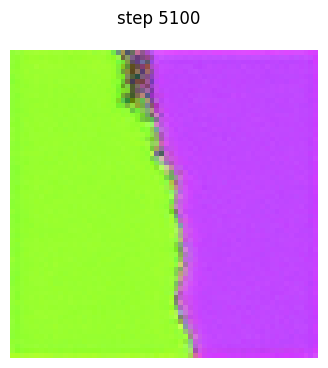

step  5101 | loss 0.0034
step  5102 | loss 0.0035
step  5103 | loss 0.0029
step  5104 | loss 0.0034
step  5105 | loss 0.0030
step  5106 | loss 0.0035
step  5107 | loss 0.0031
step  5108 | loss 0.0033
step  5109 | loss 0.0030
step  5110 | loss 0.0040
step  5111 | loss 0.0032
step  5112 | loss 0.0028
step  5113 | loss 0.0030
step  5114 | loss 0.0035
step  5115 | loss 0.0033
step  5116 | loss 0.0036
step  5117 | loss 0.0034
step  5118 | loss 0.0032
step  5119 | loss 0.0029
step  5120 | loss 0.0042
step  5121 | loss 0.0029
step  5122 | loss 0.0034
step  5123 | loss 0.0028
step  5124 | loss 0.0042
step  5125 | loss 0.0034
step  5126 | loss 0.0038
step  5127 | loss 0.0030
step  5128 | loss 0.0042
step  5129 | loss 0.0035
step  5130 | loss 0.0034
step  5131 | loss 0.0031
step  5132 | loss 0.0035
step  5133 | loss 0.0035
step  5134 | loss 0.0037
step  5135 | loss 0.0036
step  5136 | loss 0.0036
step  5137 | loss 0.0040
step  5138 | loss 0.0036
step  5139 | loss 0.0052
step  5140 | loss 0.0039


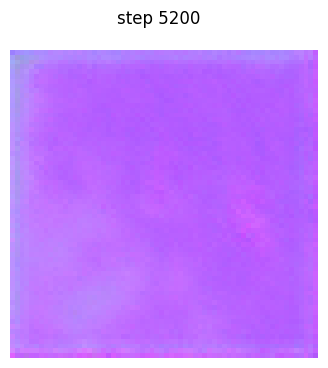

step  5201 | loss 0.0040
step  5202 | loss 0.0032
step  5203 | loss 0.0038
step  5204 | loss 0.0033
step  5205 | loss 0.0033
step  5206 | loss 0.0035
step  5207 | loss 0.0035
step  5208 | loss 0.0030
step  5209 | loss 0.0033
step  5210 | loss 0.0034
step  5211 | loss 0.0029
step  5212 | loss 0.0039
step  5213 | loss 0.0034
step  5214 | loss 0.0035
step  5215 | loss 0.0035
step  5216 | loss 0.0039
step  5217 | loss 0.0029
step  5218 | loss 0.0040
step  5219 | loss 0.0039
step  5220 | loss 0.0040
step  5221 | loss 0.0037
step  5222 | loss 0.0032
step  5223 | loss 0.0035
step  5224 | loss 0.0033
step  5225 | loss 0.0033
step  5226 | loss 0.0035
step  5227 | loss 0.0038
step  5228 | loss 0.0034
step  5229 | loss 0.0037
step  5230 | loss 0.0031
step  5231 | loss 0.0031
step  5232 | loss 0.0029
step  5233 | loss 0.0029
step  5234 | loss 0.0029
step  5235 | loss 0.0031
step  5236 | loss 0.0036
step  5237 | loss 0.0028
step  5238 | loss 0.0039
step  5239 | loss 0.0029
step  5240 | loss 0.0027


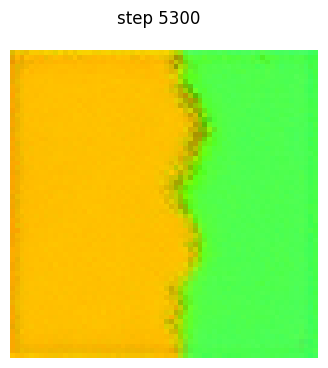

step  5301 | loss 0.0047
step  5302 | loss 0.0030
step  5303 | loss 0.0033
step  5304 | loss 0.0029
step  5305 | loss 0.0043
step  5306 | loss 0.0032
step  5307 | loss 0.0033
step  5308 | loss 0.0040
step  5309 | loss 0.0034
step  5310 | loss 0.0029
step  5311 | loss 0.0039
step  5312 | loss 0.0032
step  5313 | loss 0.0037
step  5314 | loss 0.0034
step  5315 | loss 0.0032
step  5316 | loss 0.0036
step  5317 | loss 0.0034
step  5318 | loss 0.0030
step  5319 | loss 0.0038
step  5320 | loss 0.0031
step  5321 | loss 0.0036
step  5322 | loss 0.0038
step  5323 | loss 0.0037
step  5324 | loss 0.0040
step  5325 | loss 0.0038
step  5326 | loss 0.0036
step  5327 | loss 0.0029
step  5328 | loss 0.0043
step  5329 | loss 0.0038
step  5330 | loss 0.0032
step  5331 | loss 0.0051
step  5332 | loss 0.0044
step  5333 | loss 0.0056
step  5334 | loss 0.0042
step  5335 | loss 0.0045
step  5336 | loss 0.0046
step  5337 | loss 0.0043
step  5338 | loss 0.0046
step  5339 | loss 0.0050
step  5340 | loss 0.0053


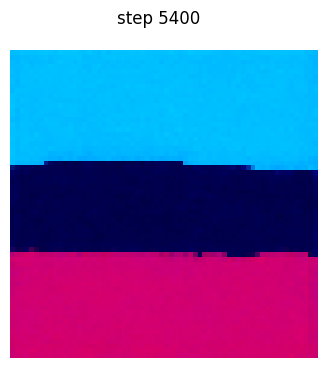

step  5401 | loss 0.0029
step  5402 | loss 0.0034
step  5403 | loss 0.0034
step  5404 | loss 0.0031
step  5405 | loss 0.0028
step  5406 | loss 0.0031
step  5407 | loss 0.0034
step  5408 | loss 0.0029
step  5409 | loss 0.0035
step  5410 | loss 0.0033
step  5411 | loss 0.0028
step  5412 | loss 0.0035
step  5413 | loss 0.0032
step  5414 | loss 0.0043
step  5415 | loss 0.0038
step  5416 | loss 0.0041
step  5417 | loss 0.0036
step  5418 | loss 0.0034
step  5419 | loss 0.0037
step  5420 | loss 0.0038
step  5421 | loss 0.0048
step  5422 | loss 0.0043
step  5423 | loss 0.0038
step  5424 | loss 0.0038
step  5425 | loss 0.0031
step  5426 | loss 0.0033
step  5427 | loss 0.0043
step  5428 | loss 0.0035
step  5429 | loss 0.0038
step  5430 | loss 0.0031
step  5431 | loss 0.0032
step  5432 | loss 0.0038
step  5433 | loss 0.0035
step  5434 | loss 0.0033
step  5435 | loss 0.0032
step  5436 | loss 0.0041
step  5437 | loss 0.0032
step  5438 | loss 0.0034
step  5439 | loss 0.0035
step  5440 | loss 0.0027


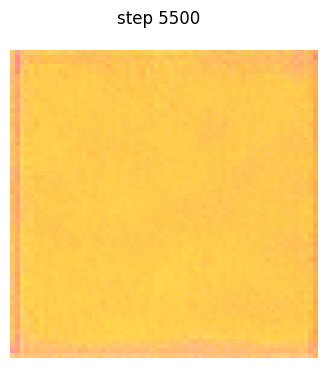

step  5501 | loss 0.0035
step  5502 | loss 0.0034
step  5503 | loss 0.0034
step  5504 | loss 0.0033
step  5505 | loss 0.0042
step  5506 | loss 0.0034
step  5507 | loss 0.0036
step  5508 | loss 0.0034
step  5509 | loss 0.0032
step  5510 | loss 0.0038
step  5511 | loss 0.0031
step  5512 | loss 0.0037
step  5513 | loss 0.0031
step  5514 | loss 0.0034
step  5515 | loss 0.0028
step  5516 | loss 0.0033
step  5517 | loss 0.0030
step  5518 | loss 0.0035
step  5519 | loss 0.0036
step  5520 | loss 0.0032
step  5521 | loss 0.0036
step  5522 | loss 0.0032
step  5523 | loss 0.0036
step  5524 | loss 0.0034
step  5525 | loss 0.0030
step  5526 | loss 0.0041
step  5527 | loss 0.0031
step  5528 | loss 0.0033
step  5529 | loss 0.0037
step  5530 | loss 0.0039
step  5531 | loss 0.0034
step  5532 | loss 0.0034
step  5533 | loss 0.0033
step  5534 | loss 0.0030
step  5535 | loss 0.0032
step  5536 | loss 0.0031
step  5537 | loss 0.0051
step  5538 | loss 0.0039
step  5539 | loss 0.0029
step  5540 | loss 0.0034


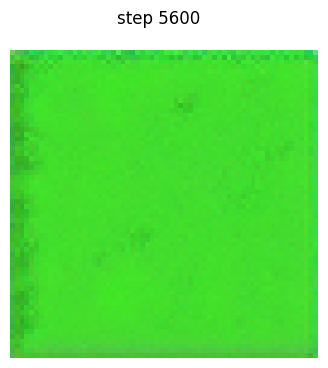

step  5601 | loss 0.0029
step  5602 | loss 0.0027
step  5603 | loss 0.0029
step  5604 | loss 0.0026
step  5605 | loss 0.0027
step  5606 | loss 0.0029
step  5607 | loss 0.0029
step  5608 | loss 0.0024
step  5609 | loss 0.0028
step  5610 | loss 0.0031
step  5611 | loss 0.0029
step  5612 | loss 0.0027
step  5613 | loss 0.0026
step  5614 | loss 0.0029
step  5615 | loss 0.0029
step  5616 | loss 0.0027
step  5617 | loss 0.0028
step  5618 | loss 0.0028
step  5619 | loss 0.0032
step  5620 | loss 0.0027
step  5621 | loss 0.0031
step  5622 | loss 0.0023
step  5623 | loss 0.0033
step  5624 | loss 0.0031
step  5625 | loss 0.0030
step  5626 | loss 0.0030
step  5627 | loss 0.0027
step  5628 | loss 0.0028
step  5629 | loss 0.0029
step  5630 | loss 0.0029
step  5631 | loss 0.0030
step  5632 | loss 0.0026
step  5633 | loss 0.0028
step  5634 | loss 0.0030
step  5635 | loss 0.0027
step  5636 | loss 0.0029
step  5637 | loss 0.0031
step  5638 | loss 0.0028
step  5639 | loss 0.0026
step  5640 | loss 0.0028


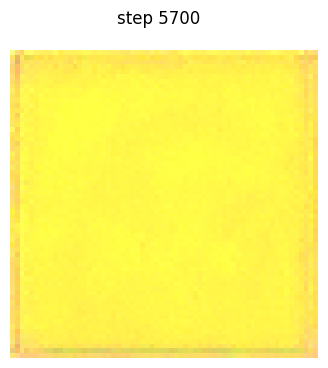

step  5701 | loss 0.0031
step  5702 | loss 0.0030
step  5703 | loss 0.0039
step  5704 | loss 0.0032
step  5705 | loss 0.0030
step  5706 | loss 0.0029
step  5707 | loss 0.0027
step  5708 | loss 0.0031
step  5709 | loss 0.0032
step  5710 | loss 0.0032
step  5711 | loss 0.0027
step  5712 | loss 0.0030
step  5713 | loss 0.0041
step  5714 | loss 0.0032
step  5715 | loss 0.0037
step  5716 | loss 0.0029
step  5717 | loss 0.0031
step  5718 | loss 0.0034
step  5719 | loss 0.0035
step  5720 | loss 0.0042
step  5721 | loss 0.0036
step  5722 | loss 0.0032
step  5723 | loss 0.0032
step  5724 | loss 0.0052
step  5725 | loss 0.0035
step  5726 | loss 0.0031
step  5727 | loss 0.0043
step  5728 | loss 0.0039
step  5729 | loss 0.0047
step  5730 | loss 0.0036
step  5731 | loss 0.0033
step  5732 | loss 0.0034
step  5733 | loss 0.0036
step  5734 | loss 0.0036
step  5735 | loss 0.0031
step  5736 | loss 0.0033
step  5737 | loss 0.0039
step  5738 | loss 0.0031
step  5739 | loss 0.0038
step  5740 | loss 0.0037


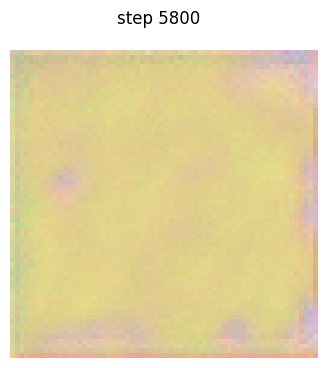

step  5801 | loss 0.0027
step  5802 | loss 0.0029
step  5803 | loss 0.0023
step  5804 | loss 0.0032
step  5805 | loss 0.0025
step  5806 | loss 0.0036
step  5807 | loss 0.0032
step  5808 | loss 0.0031
step  5809 | loss 0.0033
step  5810 | loss 0.0030
step  5811 | loss 0.0035
step  5812 | loss 0.0028
step  5813 | loss 0.0032
step  5814 | loss 0.0031
step  5815 | loss 0.0030
step  5816 | loss 0.0034
step  5817 | loss 0.0028
step  5818 | loss 0.0032
step  5819 | loss 0.0027
step  5820 | loss 0.0030
step  5821 | loss 0.0031
step  5822 | loss 0.0033
step  5823 | loss 0.0028
step  5824 | loss 0.0029
step  5825 | loss 0.0033
step  5826 | loss 0.0032
step  5827 | loss 0.0034
step  5828 | loss 0.0032
step  5829 | loss 0.0027
step  5830 | loss 0.0039
step  5831 | loss 0.0032
step  5832 | loss 0.0030
step  5833 | loss 0.0030
step  5834 | loss 0.0030
step  5835 | loss 0.0030
step  5836 | loss 0.0030
step  5837 | loss 0.0032
step  5838 | loss 0.0031
step  5839 | loss 0.0034
step  5840 | loss 0.0030


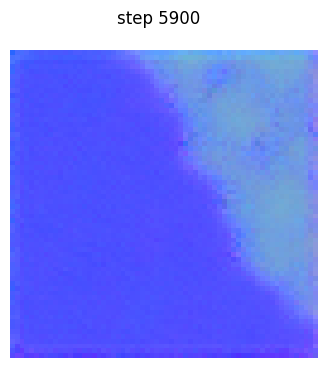

step  5901 | loss 0.0036
step  5902 | loss 0.0037
step  5903 | loss 0.0031
step  5904 | loss 0.0032
step  5905 | loss 0.0030
step  5906 | loss 0.0029
step  5907 | loss 0.0031
step  5908 | loss 0.0034
step  5909 | loss 0.0035
step  5910 | loss 0.0029
step  5911 | loss 0.0027
step  5912 | loss 0.0031
step  5913 | loss 0.0032
step  5914 | loss 0.0031
step  5915 | loss 0.0027
step  5916 | loss 0.0030
step  5917 | loss 0.0030
step  5918 | loss 0.0035
step  5919 | loss 0.0036
step  5920 | loss 0.0029
step  5921 | loss 0.0031
step  5922 | loss 0.0030
step  5923 | loss 0.0028
step  5924 | loss 0.0027
step  5925 | loss 0.0032
step  5926 | loss 0.0033
step  5927 | loss 0.0031
step  5928 | loss 0.0032
step  5929 | loss 0.0038
step  5930 | loss 0.0042
step  5931 | loss 0.0029
step  5932 | loss 0.0045
step  5933 | loss 0.0038
step  5934 | loss 0.0039
step  5935 | loss 0.0041
step  5936 | loss 0.0027
step  5937 | loss 0.0037
step  5938 | loss 0.0032
step  5939 | loss 0.0035
step  5940 | loss 0.0031


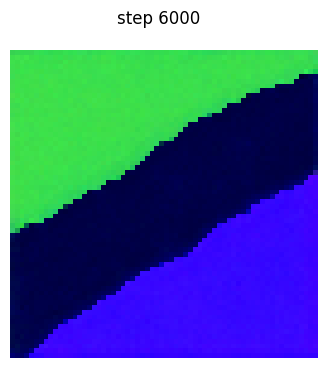

step  6001 | loss 0.0026
step  6002 | loss 0.0025
step  6003 | loss 0.0033
step  6004 | loss 0.0025
step  6005 | loss 0.0030
step  6006 | loss 0.0027
step  6007 | loss 0.0025
step  6008 | loss 0.0028
step  6009 | loss 0.0029
step  6010 | loss 0.0026
step  6011 | loss 0.0027
step  6012 | loss 0.0032
step  6013 | loss 0.0031
step  6014 | loss 0.0037
step  6015 | loss 0.0026
step  6016 | loss 0.0030
step  6017 | loss 0.0028
step  6018 | loss 0.0028
step  6019 | loss 0.0032
step  6020 | loss 0.0029
step  6021 | loss 0.0032
step  6022 | loss 0.0034
step  6023 | loss 0.0025
step  6024 | loss 0.0032
step  6025 | loss 0.0035
step  6026 | loss 0.0031
step  6027 | loss 0.0030
step  6028 | loss 0.0030
step  6029 | loss 0.0035
step  6030 | loss 0.0042
step  6031 | loss 0.0032
step  6032 | loss 0.0031
step  6033 | loss 0.0035
step  6034 | loss 0.0034
step  6035 | loss 0.0028
step  6036 | loss 0.0030
step  6037 | loss 0.0040
step  6038 | loss 0.0032
step  6039 | loss 0.0036
step  6040 | loss 0.0037


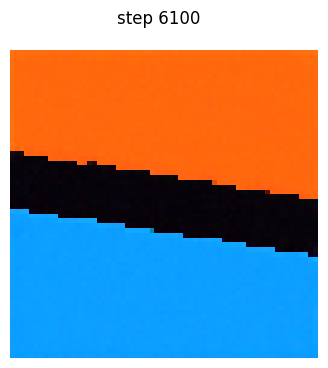

step  6101 | loss 0.0029
step  6102 | loss 0.0033
step  6103 | loss 0.0035
step  6104 | loss 0.0036
step  6105 | loss 0.0035
step  6106 | loss 0.0041
step  6107 | loss 0.0033
step  6108 | loss 0.0030
step  6109 | loss 0.0034
step  6110 | loss 0.0033
step  6111 | loss 0.0031
step  6112 | loss 0.0031
step  6113 | loss 0.0038
step  6114 | loss 0.0031
step  6115 | loss 0.0033
step  6116 | loss 0.0030
step  6117 | loss 0.0027
step  6118 | loss 0.0031
step  6119 | loss 0.0037
step  6120 | loss 0.0032
step  6121 | loss 0.0033
step  6122 | loss 0.0031
step  6123 | loss 0.0030
step  6124 | loss 0.0033
step  6125 | loss 0.0032
step  6126 | loss 0.0034
step  6127 | loss 0.0037
step  6128 | loss 0.0036
step  6129 | loss 0.0033
step  6130 | loss 0.0031
step  6131 | loss 0.0042
step  6132 | loss 0.0031
step  6133 | loss 0.0034
step  6134 | loss 0.0035
step  6135 | loss 0.0033
step  6136 | loss 0.0039
step  6137 | loss 0.0033
step  6138 | loss 0.0038
step  6139 | loss 0.0028
step  6140 | loss 0.0028


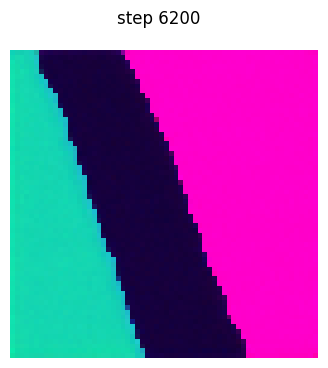

step  6201 | loss 0.0028
step  6202 | loss 0.0027
step  6203 | loss 0.0025
step  6204 | loss 0.0035
step  6205 | loss 0.0029
step  6206 | loss 0.0027
step  6207 | loss 0.0031
step  6208 | loss 0.0024
step  6209 | loss 0.0031
step  6210 | loss 0.0027
step  6211 | loss 0.0034
step  6212 | loss 0.0029
step  6213 | loss 0.0029
step  6214 | loss 0.0029
step  6215 | loss 0.0028
step  6216 | loss 0.0030
step  6217 | loss 0.0030
step  6218 | loss 0.0027
step  6219 | loss 0.0030
step  6220 | loss 0.0023
step  6221 | loss 0.0027
step  6222 | loss 0.0025
step  6223 | loss 0.0036
step  6224 | loss 0.0028
step  6225 | loss 0.0032
step  6226 | loss 0.0029
step  6227 | loss 0.0028
step  6228 | loss 0.0031
step  6229 | loss 0.0037
step  6230 | loss 0.0038
step  6231 | loss 0.0032
step  6232 | loss 0.0034
step  6233 | loss 0.0034
step  6234 | loss 0.0032
step  6235 | loss 0.0032
step  6236 | loss 0.0038
step  6237 | loss 0.0032
step  6238 | loss 0.0037
step  6239 | loss 0.0033
step  6240 | loss 0.0040


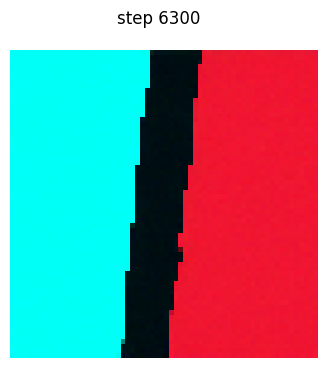

step  6301 | loss 0.0033
step  6302 | loss 0.0028
step  6303 | loss 0.0030
step  6304 | loss 0.0027
step  6305 | loss 0.0029
step  6306 | loss 0.0028
step  6307 | loss 0.0025
step  6308 | loss 0.0032
step  6309 | loss 0.0024
step  6310 | loss 0.0024
step  6311 | loss 0.0028
step  6312 | loss 0.0028
step  6313 | loss 0.0028
step  6314 | loss 0.0024
step  6315 | loss 0.0028
step  6316 | loss 0.0027
step  6317 | loss 0.0025
step  6318 | loss 0.0026
step  6319 | loss 0.0027
step  6320 | loss 0.0024
step  6321 | loss 0.0025
step  6322 | loss 0.0023
step  6323 | loss 0.0026
step  6324 | loss 0.0026
step  6325 | loss 0.0023
step  6326 | loss 0.0027
step  6327 | loss 0.0027
step  6328 | loss 0.0030
step  6329 | loss 0.0033
step  6330 | loss 0.0029
step  6331 | loss 0.0034
step  6332 | loss 0.0028
step  6333 | loss 0.0030
step  6334 | loss 0.0029
step  6335 | loss 0.0029
step  6336 | loss 0.0026
step  6337 | loss 0.0029
step  6338 | loss 0.0026
step  6339 | loss 0.0030
step  6340 | loss 0.0032


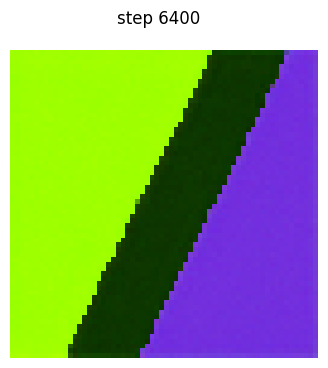

step  6401 | loss 0.0031
step  6402 | loss 0.0030
step  6403 | loss 0.0030
step  6404 | loss 0.0028
step  6405 | loss 0.0026
step  6406 | loss 0.0029
step  6407 | loss 0.0032
step  6408 | loss 0.0025
step  6409 | loss 0.0026
step  6410 | loss 0.0028
step  6411 | loss 0.0023
step  6412 | loss 0.0025
step  6413 | loss 0.0026
step  6414 | loss 0.0028
step  6415 | loss 0.0028
step  6416 | loss 0.0030
step  6417 | loss 0.0030
step  6418 | loss 0.0029
step  6419 | loss 0.0033
step  6420 | loss 0.0030
step  6421 | loss 0.0029
step  6422 | loss 0.0033
step  6423 | loss 0.0037
step  6424 | loss 0.0028
step  6425 | loss 0.0038
step  6426 | loss 0.0027
step  6427 | loss 0.0031
step  6428 | loss 0.0031
step  6429 | loss 0.0028
step  6430 | loss 0.0031
step  6431 | loss 0.0023
step  6432 | loss 0.0031
step  6433 | loss 0.0030
step  6434 | loss 0.0028
step  6435 | loss 0.0033
step  6436 | loss 0.0027
step  6437 | loss 0.0028
step  6438 | loss 0.0029
step  6439 | loss 0.0027
step  6440 | loss 0.0026


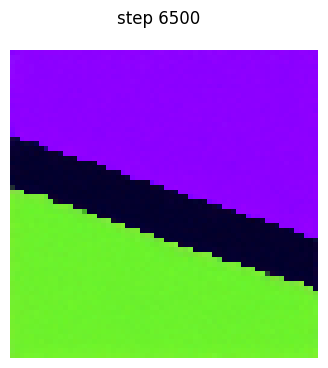

step  6501 | loss 0.0028
step  6502 | loss 0.0028
step  6503 | loss 0.0030
step  6504 | loss 0.0027
step  6505 | loss 0.0026
step  6506 | loss 0.0027
step  6507 | loss 0.0028
step  6508 | loss 0.0029
step  6509 | loss 0.0028
step  6510 | loss 0.0031
step  6511 | loss 0.0028
step  6512 | loss 0.0026
step  6513 | loss 0.0039
step  6514 | loss 0.0025
step  6515 | loss 0.0029
step  6516 | loss 0.0026
step  6517 | loss 0.0029
step  6518 | loss 0.0030
step  6519 | loss 0.0024
step  6520 | loss 0.0028
step  6521 | loss 0.0026
step  6522 | loss 0.0044
step  6523 | loss 0.0031
step  6524 | loss 0.0035
step  6525 | loss 0.0027
step  6526 | loss 0.0038
step  6527 | loss 0.0029
step  6528 | loss 0.0043
step  6529 | loss 0.0039
step  6530 | loss 0.0033
step  6531 | loss 0.0038
step  6532 | loss 0.0034
step  6533 | loss 0.0028
step  6534 | loss 0.0031
step  6535 | loss 0.0031
step  6536 | loss 0.0030
step  6537 | loss 0.0035
step  6538 | loss 0.0031
step  6539 | loss 0.0032
step  6540 | loss 0.0030


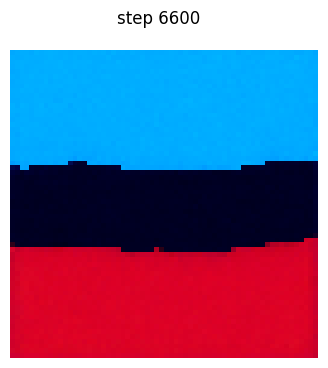

step  6601 | loss 0.0026
step  6602 | loss 0.0024
step  6603 | loss 0.0026
step  6604 | loss 0.0028
step  6605 | loss 0.0028
step  6606 | loss 0.0027
step  6607 | loss 0.0028
step  6608 | loss 0.0032
step  6609 | loss 0.0026
step  6610 | loss 0.0028
step  6611 | loss 0.0026
step  6612 | loss 0.0024
step  6613 | loss 0.0025
step  6614 | loss 0.0026
step  6615 | loss 0.0029
step  6616 | loss 0.0028
step  6617 | loss 0.0028
step  6618 | loss 0.0027
step  6619 | loss 0.0026
step  6620 | loss 0.0033
step  6621 | loss 0.0025
step  6622 | loss 0.0027
step  6623 | loss 0.0037
step  6624 | loss 0.0028
step  6625 | loss 0.0030
step  6626 | loss 0.0040
step  6627 | loss 0.0027
step  6628 | loss 0.0033
step  6629 | loss 0.0030
step  6630 | loss 0.0030
step  6631 | loss 0.0028
step  6632 | loss 0.0027
step  6633 | loss 0.0031
step  6634 | loss 0.0033
step  6635 | loss 0.0029
step  6636 | loss 0.0038
step  6637 | loss 0.0039
step  6638 | loss 0.0037
step  6639 | loss 0.0035
step  6640 | loss 0.0032


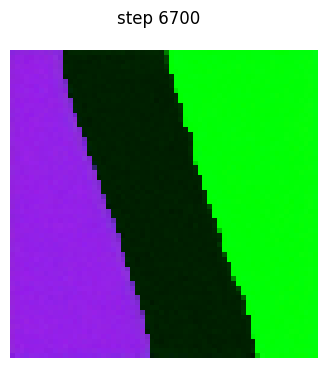

step  6701 | loss 0.0027
step  6702 | loss 0.0026
step  6703 | loss 0.0023
step  6704 | loss 0.0025
step  6705 | loss 0.0025
step  6706 | loss 0.0025
step  6707 | loss 0.0027
step  6708 | loss 0.0024
step  6709 | loss 0.0027
step  6710 | loss 0.0023
step  6711 | loss 0.0024
step  6712 | loss 0.0024
step  6713 | loss 0.0024
step  6714 | loss 0.0027
step  6715 | loss 0.0023
step  6716 | loss 0.0023
step  6717 | loss 0.0025
step  6718 | loss 0.0023
step  6719 | loss 0.0025
step  6720 | loss 0.0024
step  6721 | loss 0.0029
step  6722 | loss 0.0023
step  6723 | loss 0.0024
step  6724 | loss 0.0027
step  6725 | loss 0.0026
step  6726 | loss 0.0025
step  6727 | loss 0.0026
step  6728 | loss 0.0028
step  6729 | loss 0.0024
step  6730 | loss 0.0021
step  6731 | loss 0.0030
step  6732 | loss 0.0024
step  6733 | loss 0.0023
step  6734 | loss 0.0025
step  6735 | loss 0.0026
step  6736 | loss 0.0023
step  6737 | loss 0.0026
step  6738 | loss 0.0023
step  6739 | loss 0.0025
step  6740 | loss 0.0024


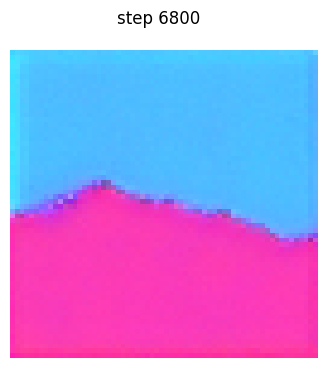

step  6801 | loss 0.0029
step  6802 | loss 0.0029
step  6803 | loss 0.0029
step  6804 | loss 0.0029
step  6805 | loss 0.0028
step  6806 | loss 0.0027
step  6807 | loss 0.0026
step  6808 | loss 0.0027
step  6809 | loss 0.0031
step  6810 | loss 0.0029
step  6811 | loss 0.0027
step  6812 | loss 0.0029
step  6813 | loss 0.0027
step  6814 | loss 0.0029
step  6815 | loss 0.0030
step  6816 | loss 0.0033
step  6817 | loss 0.0035
step  6818 | loss 0.0032
step  6819 | loss 0.0033
step  6820 | loss 0.0039
step  6821 | loss 0.0030
step  6822 | loss 0.0026
step  6823 | loss 0.0031
step  6824 | loss 0.0033
step  6825 | loss 0.0026
step  6826 | loss 0.0031
step  6827 | loss 0.0023
step  6828 | loss 0.0039
step  6829 | loss 0.0041
step  6830 | loss 0.0031
step  6831 | loss 0.0036
step  6832 | loss 0.0028
step  6833 | loss 0.0026
step  6834 | loss 0.0031
step  6835 | loss 0.0029
step  6836 | loss 0.0027
step  6837 | loss 0.0027
step  6838 | loss 0.0033
step  6839 | loss 0.0025
step  6840 | loss 0.0027


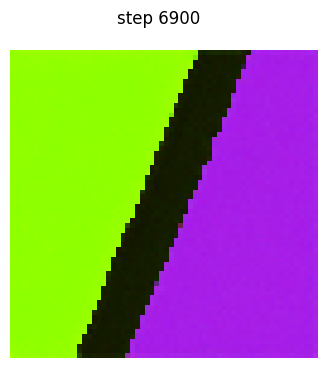

step  6901 | loss 0.0028
step  6902 | loss 0.0026
step  6903 | loss 0.0028
step  6904 | loss 0.0035
step  6905 | loss 0.0028
step  6906 | loss 0.0035
step  6907 | loss 0.0029
step  6908 | loss 0.0029
step  6909 | loss 0.0040
step  6910 | loss 0.0035
step  6911 | loss 0.0031
step  6912 | loss 0.0028
step  6913 | loss 0.0029
step  6914 | loss 0.0027
step  6915 | loss 0.0027
step  6916 | loss 0.0026
step  6917 | loss 0.0032
step  6918 | loss 0.0029
step  6919 | loss 0.0027
step  6920 | loss 0.0031
step  6921 | loss 0.0025
step  6922 | loss 0.0026
step  6923 | loss 0.0037
step  6924 | loss 0.0030
step  6925 | loss 0.0025
step  6926 | loss 0.0030
step  6927 | loss 0.0023
step  6928 | loss 0.0032
step  6929 | loss 0.0026
step  6930 | loss 0.0027
step  6931 | loss 0.0034
step  6932 | loss 0.0027
step  6933 | loss 0.0034
step  6934 | loss 0.0025
step  6935 | loss 0.0026
step  6936 | loss 0.0027
step  6937 | loss 0.0029
step  6938 | loss 0.0022
step  6939 | loss 0.0025
step  6940 | loss 0.0025


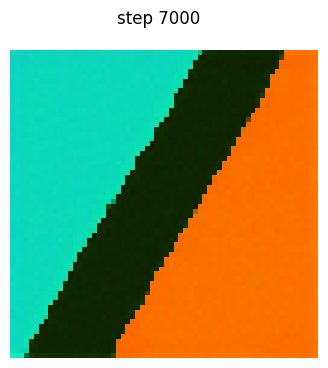

step  7001 | loss 0.0028
step  7002 | loss 0.0026
step  7003 | loss 0.0022
step  7004 | loss 0.0021
step  7005 | loss 0.0025
step  7006 | loss 0.0031
step  7007 | loss 0.0031
step  7008 | loss 0.0023
step  7009 | loss 0.0029
step  7010 | loss 0.0027
step  7011 | loss 0.0027
step  7012 | loss 0.0034
step  7013 | loss 0.0032
step  7014 | loss 0.0028
step  7015 | loss 0.0041
step  7016 | loss 0.0026
step  7017 | loss 0.0027
step  7018 | loss 0.0031
step  7019 | loss 0.0030
step  7020 | loss 0.0032
step  7021 | loss 0.0027
step  7022 | loss 0.0025
step  7023 | loss 0.0033
step  7024 | loss 0.0027
step  7025 | loss 0.0034
step  7026 | loss 0.0027
step  7027 | loss 0.0027
step  7028 | loss 0.0026
step  7029 | loss 0.0033
step  7030 | loss 0.0029
step  7031 | loss 0.0030
step  7032 | loss 0.0030
step  7033 | loss 0.0026
step  7034 | loss 0.0028
step  7035 | loss 0.0028
step  7036 | loss 0.0039
step  7037 | loss 0.0029
step  7038 | loss 0.0032
step  7039 | loss 0.0030
step  7040 | loss 0.0030


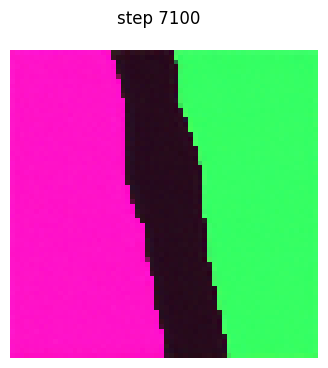

step  7101 | loss 0.0025
step  7102 | loss 0.0029
step  7103 | loss 0.0024
step  7104 | loss 0.0023
step  7105 | loss 0.0023
step  7106 | loss 0.0023
step  7107 | loss 0.0024
step  7108 | loss 0.0024
step  7109 | loss 0.0023
step  7110 | loss 0.0023
step  7111 | loss 0.0024
step  7112 | loss 0.0023
step  7113 | loss 0.0027
step  7114 | loss 0.0027
step  7115 | loss 0.0026
step  7116 | loss 0.0035
step  7117 | loss 0.0029
step  7118 | loss 0.0030
step  7119 | loss 0.0026
step  7120 | loss 0.0032
step  7121 | loss 0.0034
step  7122 | loss 0.0031
step  7123 | loss 0.0023
step  7124 | loss 0.0029
step  7125 | loss 0.0030
step  7126 | loss 0.0025
step  7127 | loss 0.0025
step  7128 | loss 0.0033
step  7129 | loss 0.0026
step  7130 | loss 0.0035
step  7131 | loss 0.0025
step  7132 | loss 0.0029
step  7133 | loss 0.0027
step  7134 | loss 0.0028
step  7135 | loss 0.0036
step  7136 | loss 0.0029
step  7137 | loss 0.0033
step  7138 | loss 0.0027
step  7139 | loss 0.0026
step  7140 | loss 0.0029


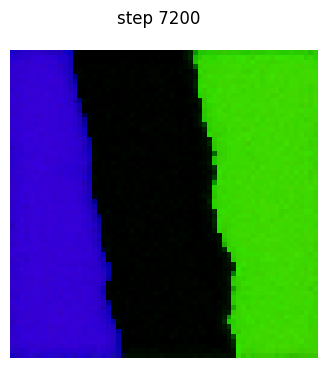

step  7201 | loss 0.0026
step  7202 | loss 0.0025
step  7203 | loss 0.0027
step  7204 | loss 0.0025
step  7205 | loss 0.0026
step  7206 | loss 0.0028
step  7207 | loss 0.0028
step  7208 | loss 0.0026
step  7209 | loss 0.0022
step  7210 | loss 0.0025
step  7211 | loss 0.0022
step  7212 | loss 0.0023
step  7213 | loss 0.0024
step  7214 | loss 0.0025
step  7215 | loss 0.0026
step  7216 | loss 0.0024
step  7217 | loss 0.0027
step  7218 | loss 0.0027
step  7219 | loss 0.0022
step  7220 | loss 0.0021
step  7221 | loss 0.0021
step  7222 | loss 0.0028
step  7223 | loss 0.0026
step  7224 | loss 0.0022
step  7225 | loss 0.0026
step  7226 | loss 0.0028
step  7227 | loss 0.0023
step  7228 | loss 0.0027
step  7229 | loss 0.0029
step  7230 | loss 0.0026
step  7231 | loss 0.0030
step  7232 | loss 0.0023
step  7233 | loss 0.0023
step  7234 | loss 0.0026
step  7235 | loss 0.0028
step  7236 | loss 0.0029
step  7237 | loss 0.0025
step  7238 | loss 0.0021
step  7239 | loss 0.0030
step  7240 | loss 0.0023


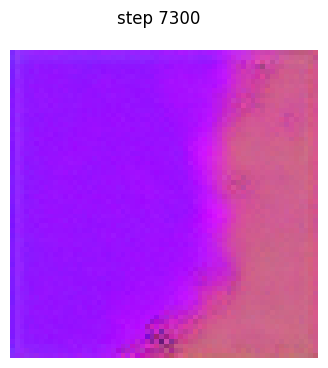

step  7301 | loss 0.0024
step  7302 | loss 0.0024
step  7303 | loss 0.0025
step  7304 | loss 0.0024
step  7305 | loss 0.0021
step  7306 | loss 0.0023
step  7307 | loss 0.0031
step  7308 | loss 0.0027
step  7309 | loss 0.0023
step  7310 | loss 0.0022
step  7311 | loss 0.0028
step  7312 | loss 0.0023
step  7313 | loss 0.0027
step  7314 | loss 0.0028
step  7315 | loss 0.0024
step  7316 | loss 0.0026
step  7317 | loss 0.0025
step  7318 | loss 0.0027
step  7319 | loss 0.0033
step  7320 | loss 0.0025
step  7321 | loss 0.0021
step  7322 | loss 0.0023
step  7323 | loss 0.0025
step  7324 | loss 0.0023
step  7325 | loss 0.0024
step  7326 | loss 0.0023
step  7327 | loss 0.0025
step  7328 | loss 0.0023
step  7329 | loss 0.0023
step  7330 | loss 0.0023
step  7331 | loss 0.0024
step  7332 | loss 0.0027
step  7333 | loss 0.0024
step  7334 | loss 0.0030
step  7335 | loss 0.0023
step  7336 | loss 0.0028
step  7337 | loss 0.0023
step  7338 | loss 0.0025
step  7339 | loss 0.0030
step  7340 | loss 0.0025


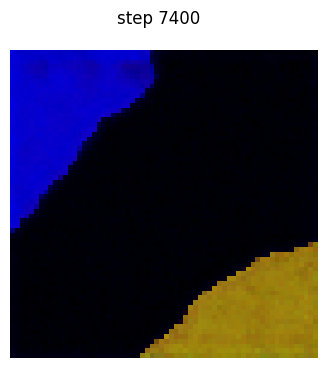

step  7401 | loss 0.0022
step  7402 | loss 0.0031
step  7403 | loss 0.0024
step  7404 | loss 0.0023
step  7405 | loss 0.0027
step  7406 | loss 0.0023
step  7407 | loss 0.0023
step  7408 | loss 0.0024
step  7409 | loss 0.0026
step  7410 | loss 0.0025
step  7411 | loss 0.0022
step  7412 | loss 0.0025
step  7413 | loss 0.0026
step  7414 | loss 0.0023
step  7415 | loss 0.0027
step  7416 | loss 0.0025
step  7417 | loss 0.0027
step  7418 | loss 0.0028
step  7419 | loss 0.0029
step  7420 | loss 0.0023
step  7421 | loss 0.0026
step  7422 | loss 0.0026
step  7423 | loss 0.0023
step  7424 | loss 0.0028
step  7425 | loss 0.0024
step  7426 | loss 0.0029
step  7427 | loss 0.0025
step  7428 | loss 0.0023
step  7429 | loss 0.0024
step  7430 | loss 0.0028
step  7431 | loss 0.0024
step  7432 | loss 0.0025
step  7433 | loss 0.0028
step  7434 | loss 0.0023
step  7435 | loss 0.0028
step  7436 | loss 0.0022
step  7437 | loss 0.0023
step  7438 | loss 0.0024
step  7439 | loss 0.0023
step  7440 | loss 0.0021


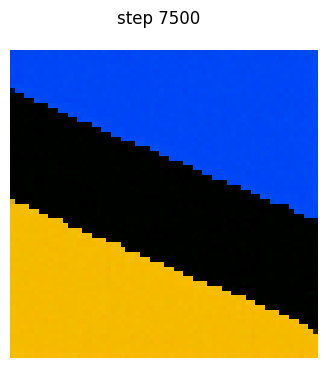

step  7501 | loss 0.0025
step  7502 | loss 0.0026
step  7503 | loss 0.0029
step  7504 | loss 0.0026
step  7505 | loss 0.0025
step  7506 | loss 0.0026
step  7507 | loss 0.0026
step  7508 | loss 0.0031
step  7509 | loss 0.0026
step  7510 | loss 0.0025
step  7511 | loss 0.0023
step  7512 | loss 0.0031
step  7513 | loss 0.0027
step  7514 | loss 0.0032
step  7515 | loss 0.0031
step  7516 | loss 0.0028
step  7517 | loss 0.0025
step  7518 | loss 0.0033
step  7519 | loss 0.0030
step  7520 | loss 0.0038
step  7521 | loss 0.0035
step  7522 | loss 0.0032
step  7523 | loss 0.0040
step  7524 | loss 0.0047
step  7525 | loss 0.0031
step  7526 | loss 0.0034
step  7527 | loss 0.0037
step  7528 | loss 0.0041
step  7529 | loss 0.0031
step  7530 | loss 0.0028
step  7531 | loss 0.0036
step  7532 | loss 0.0029
step  7533 | loss 0.0032
step  7534 | loss 0.0035
step  7535 | loss 0.0028
step  7536 | loss 0.0027
step  7537 | loss 0.0033
step  7538 | loss 0.0025
step  7539 | loss 0.0032
step  7540 | loss 0.0029


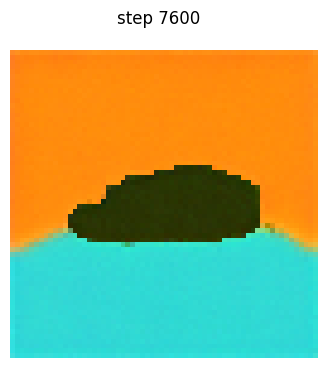

step  7601 | loss 0.0032
step  7602 | loss 0.0023
step  7603 | loss 0.0022
step  7604 | loss 0.0031
step  7605 | loss 0.0027
step  7606 | loss 0.0028
step  7607 | loss 0.0024
step  7608 | loss 0.0025
step  7609 | loss 0.0027
step  7610 | loss 0.0030
step  7611 | loss 0.0032
step  7612 | loss 0.0027
step  7613 | loss 0.0025
step  7614 | loss 0.0023
step  7615 | loss 0.0029
step  7616 | loss 0.0024
step  7617 | loss 0.0032
step  7618 | loss 0.0026
step  7619 | loss 0.0025
step  7620 | loss 0.0026
step  7621 | loss 0.0034
step  7622 | loss 0.0032
step  7623 | loss 0.0030
step  7624 | loss 0.0029
step  7625 | loss 0.0033
step  7626 | loss 0.0033
step  7627 | loss 0.0030
step  7628 | loss 0.0035
step  7629 | loss 0.0029
step  7630 | loss 0.0030
step  7631 | loss 0.0032
step  7632 | loss 0.0033
step  7633 | loss 0.0030
step  7634 | loss 0.0036
step  7635 | loss 0.0028
step  7636 | loss 0.0029
step  7637 | loss 0.0038
step  7638 | loss 0.0027
step  7639 | loss 0.0034
step  7640 | loss 0.0038


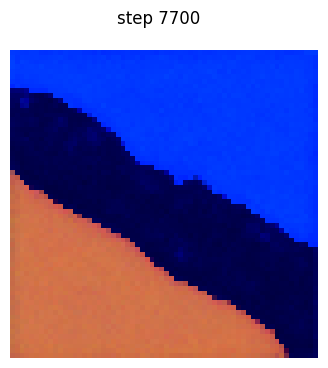

step  7701 | loss 0.0027
step  7702 | loss 0.0030
step  7703 | loss 0.0027
step  7704 | loss 0.0028
step  7705 | loss 0.0030
step  7706 | loss 0.0031
step  7707 | loss 0.0028
step  7708 | loss 0.0028
step  7709 | loss 0.0029
step  7710 | loss 0.0025
step  7711 | loss 0.0032
step  7712 | loss 0.0026
step  7713 | loss 0.0027
step  7714 | loss 0.0027
step  7715 | loss 0.0032
step  7716 | loss 0.0031
step  7717 | loss 0.0032
step  7718 | loss 0.0033
step  7719 | loss 0.0031
step  7720 | loss 0.0025
step  7721 | loss 0.0023
step  7722 | loss 0.0025
step  7723 | loss 0.0029
step  7724 | loss 0.0025
step  7725 | loss 0.0027
step  7726 | loss 0.0027
step  7727 | loss 0.0023
step  7728 | loss 0.0025
step  7729 | loss 0.0021
step  7730 | loss 0.0025
step  7731 | loss 0.0025
step  7732 | loss 0.0023
step  7733 | loss 0.0028
step  7734 | loss 0.0021
step  7735 | loss 0.0026
step  7736 | loss 0.0023
step  7737 | loss 0.0026
step  7738 | loss 0.0029
step  7739 | loss 0.0022
step  7740 | loss 0.0022


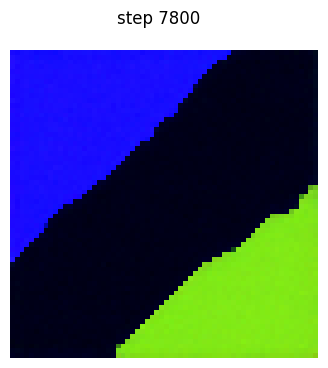

step  7801 | loss 0.0021
step  7802 | loss 0.0020
step  7803 | loss 0.0019
step  7804 | loss 0.0019
step  7805 | loss 0.0020
step  7806 | loss 0.0018
step  7807 | loss 0.0021
step  7808 | loss 0.0021
step  7809 | loss 0.0021
step  7810 | loss 0.0019
step  7811 | loss 0.0023
step  7812 | loss 0.0019
step  7813 | loss 0.0024
step  7814 | loss 0.0022
step  7815 | loss 0.0022
step  7816 | loss 0.0024
step  7817 | loss 0.0022
step  7818 | loss 0.0020
step  7819 | loss 0.0022
step  7820 | loss 0.0021
step  7821 | loss 0.0022
step  7822 | loss 0.0026
step  7823 | loss 0.0020
step  7824 | loss 0.0025
step  7825 | loss 0.0020
step  7826 | loss 0.0023
step  7827 | loss 0.0026
step  7828 | loss 0.0021
step  7829 | loss 0.0033
step  7830 | loss 0.0029
step  7831 | loss 0.0023
step  7832 | loss 0.0032
step  7833 | loss 0.0036
step  7834 | loss 0.0038
step  7835 | loss 0.0030
step  7836 | loss 0.0032
step  7837 | loss 0.0025
step  7838 | loss 0.0029
step  7839 | loss 0.0035
step  7840 | loss 0.0025


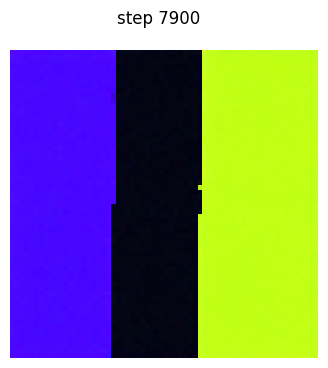

step  7901 | loss 0.0025
step  7902 | loss 0.0023
step  7903 | loss 0.0021
step  7904 | loss 0.0027
step  7905 | loss 0.0022
step  7906 | loss 0.0025
step  7907 | loss 0.0022
step  7908 | loss 0.0022
step  7909 | loss 0.0023
step  7910 | loss 0.0025
step  7911 | loss 0.0021
step  7912 | loss 0.0023
step  7913 | loss 0.0022
step  7914 | loss 0.0020
step  7915 | loss 0.0026
step  7916 | loss 0.0023
step  7917 | loss 0.0022
step  7918 | loss 0.0023
step  7919 | loss 0.0026
step  7920 | loss 0.0022
step  7921 | loss 0.0024
step  7922 | loss 0.0027
step  7923 | loss 0.0026
step  7924 | loss 0.0022
step  7925 | loss 0.0022
step  7926 | loss 0.0024
step  7927 | loss 0.0026
step  7928 | loss 0.0026
step  7929 | loss 0.0025
step  7930 | loss 0.0026
step  7931 | loss 0.0025
step  7932 | loss 0.0027
step  7933 | loss 0.0028
step  7934 | loss 0.0029
step  7935 | loss 0.0031
step  7936 | loss 0.0038
step  7937 | loss 0.0028
step  7938 | loss 0.0032
step  7939 | loss 0.0025
step  7940 | loss 0.0029


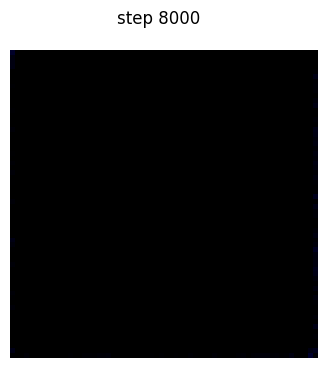

step  8001 | loss 0.0024
step  8002 | loss 0.0024
step  8003 | loss 0.0027
step  8004 | loss 0.0026
step  8005 | loss 0.0028
step  8006 | loss 0.0028
step  8007 | loss 0.0025
step  8008 | loss 0.0028
step  8009 | loss 0.0027
step  8010 | loss 0.0026
step  8011 | loss 0.0023
step  8012 | loss 0.0027
step  8013 | loss 0.0028
step  8014 | loss 0.0021
step  8015 | loss 0.0020
step  8016 | loss 0.0024
step  8017 | loss 0.0024
step  8018 | loss 0.0019
step  8019 | loss 0.0025
step  8020 | loss 0.0021
step  8021 | loss 0.0022
step  8022 | loss 0.0026
step  8023 | loss 0.0020
step  8024 | loss 0.0022
step  8025 | loss 0.0020
step  8026 | loss 0.0023
step  8027 | loss 0.0018
step  8028 | loss 0.0022
step  8029 | loss 0.0019
step  8030 | loss 0.0025
step  8031 | loss 0.0021
step  8032 | loss 0.0026
step  8033 | loss 0.0026
step  8034 | loss 0.0030
step  8035 | loss 0.0025
step  8036 | loss 0.0023
step  8037 | loss 0.0026
step  8038 | loss 0.0022
step  8039 | loss 0.0021
step  8040 | loss 0.0023


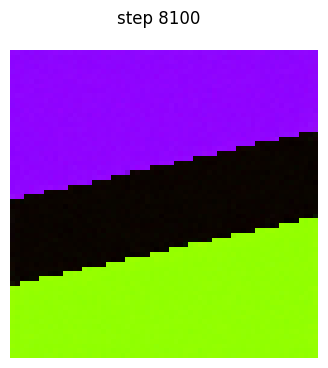

step  8101 | loss 0.0028
step  8102 | loss 0.0024
step  8103 | loss 0.0027
step  8104 | loss 0.0026
step  8105 | loss 0.0025
step  8106 | loss 0.0023
step  8107 | loss 0.0028
step  8108 | loss 0.0022
step  8109 | loss 0.0020
step  8110 | loss 0.0024
step  8111 | loss 0.0022
step  8112 | loss 0.0022
step  8113 | loss 0.0021
step  8114 | loss 0.0024
step  8115 | loss 0.0028
step  8116 | loss 0.0018
step  8117 | loss 0.0024
step  8118 | loss 0.0020
step  8119 | loss 0.0025
step  8120 | loss 0.0021
step  8121 | loss 0.0021
step  8122 | loss 0.0025
step  8123 | loss 0.0023
step  8124 | loss 0.0021
step  8125 | loss 0.0022
step  8126 | loss 0.0021
step  8127 | loss 0.0022
step  8128 | loss 0.0020
step  8129 | loss 0.0022
step  8130 | loss 0.0024
step  8131 | loss 0.0022
step  8132 | loss 0.0020
step  8133 | loss 0.0021
step  8134 | loss 0.0019
step  8135 | loss 0.0021
step  8136 | loss 0.0021
step  8137 | loss 0.0025
step  8138 | loss 0.0022
step  8139 | loss 0.0021
step  8140 | loss 0.0023


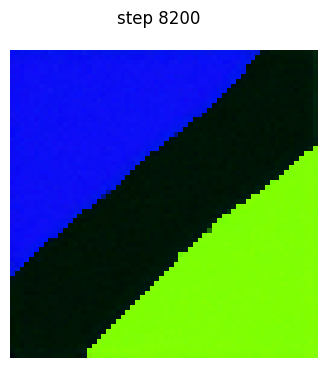

step  8201 | loss 0.0024
step  8202 | loss 0.0024
step  8203 | loss 0.0023
step  8204 | loss 0.0026
step  8205 | loss 0.0027
step  8206 | loss 0.0024
step  8207 | loss 0.0026
step  8208 | loss 0.0021
step  8209 | loss 0.0024
step  8210 | loss 0.0025
step  8211 | loss 0.0024
step  8212 | loss 0.0029
step  8213 | loss 0.0023
step  8214 | loss 0.0024
step  8215 | loss 0.0029
step  8216 | loss 0.0023
step  8217 | loss 0.0030
step  8218 | loss 0.0029
step  8219 | loss 0.0022
step  8220 | loss 0.0024
step  8221 | loss 0.0032
step  8222 | loss 0.0029
step  8223 | loss 0.0026
step  8224 | loss 0.0027
step  8225 | loss 0.0029
step  8226 | loss 0.0024
step  8227 | loss 0.0027
step  8228 | loss 0.0030
step  8229 | loss 0.0029
step  8230 | loss 0.0033
step  8231 | loss 0.0023
step  8232 | loss 0.0022
step  8233 | loss 0.0026
step  8234 | loss 0.0021
step  8235 | loss 0.0022
step  8236 | loss 0.0023
step  8237 | loss 0.0025
step  8238 | loss 0.0020
step  8239 | loss 0.0024
step  8240 | loss 0.0027


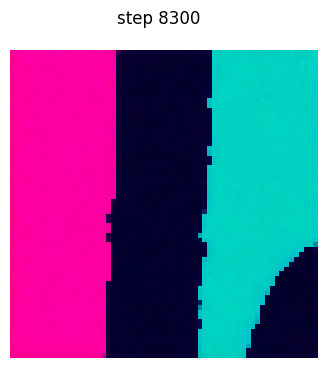

step  8301 | loss 0.0022
step  8302 | loss 0.0025
step  8303 | loss 0.0023
step  8304 | loss 0.0019
step  8305 | loss 0.0020
step  8306 | loss 0.0027
step  8307 | loss 0.0021
step  8308 | loss 0.0023
step  8309 | loss 0.0023
step  8310 | loss 0.0022
step  8311 | loss 0.0019
step  8312 | loss 0.0023
step  8313 | loss 0.0021
step  8314 | loss 0.0024
step  8315 | loss 0.0019
step  8316 | loss 0.0022
step  8317 | loss 0.0027
step  8318 | loss 0.0023
step  8319 | loss 0.0021
step  8320 | loss 0.0021
step  8321 | loss 0.0021
step  8322 | loss 0.0021
step  8323 | loss 0.0020
step  8324 | loss 0.0021
step  8325 | loss 0.0021
step  8326 | loss 0.0020
step  8327 | loss 0.0020
step  8328 | loss 0.0023
step  8329 | loss 0.0022
step  8330 | loss 0.0023
step  8331 | loss 0.0019
step  8332 | loss 0.0021
step  8333 | loss 0.0021
step  8334 | loss 0.0023
step  8335 | loss 0.0018
step  8336 | loss 0.0022
step  8337 | loss 0.0023
step  8338 | loss 0.0024
step  8339 | loss 0.0027
step  8340 | loss 0.0030


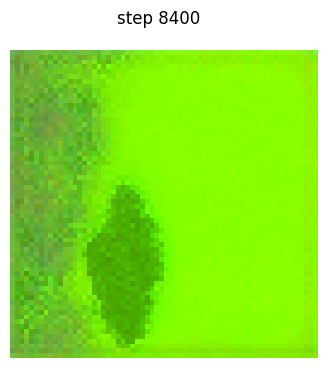

step  8401 | loss 0.0025
step  8402 | loss 0.0026
step  8403 | loss 0.0026
step  8404 | loss 0.0022
step  8405 | loss 0.0022
step  8406 | loss 0.0024
step  8407 | loss 0.0021
step  8408 | loss 0.0020
step  8409 | loss 0.0024
step  8410 | loss 0.0021
step  8411 | loss 0.0018
step  8412 | loss 0.0020
step  8413 | loss 0.0022
step  8414 | loss 0.0020
step  8415 | loss 0.0023
step  8416 | loss 0.0021
step  8417 | loss 0.0023
step  8418 | loss 0.0024
step  8419 | loss 0.0021
step  8420 | loss 0.0024
step  8421 | loss 0.0020
step  8422 | loss 0.0022
step  8423 | loss 0.0024
step  8424 | loss 0.0027
step  8425 | loss 0.0021
step  8426 | loss 0.0020
step  8427 | loss 0.0025
step  8428 | loss 0.0026
step  8429 | loss 0.0022
step  8430 | loss 0.0019
step  8431 | loss 0.0026
step  8432 | loss 0.0022
step  8433 | loss 0.0024
step  8434 | loss 0.0024
step  8435 | loss 0.0027
step  8436 | loss 0.0022
step  8437 | loss 0.0022
step  8438 | loss 0.0019
step  8439 | loss 0.0022
step  8440 | loss 0.0022


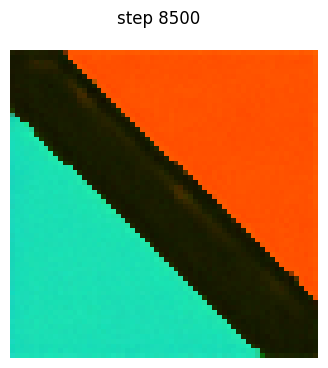

step  8501 | loss 0.0024
step  8502 | loss 0.0022
step  8503 | loss 0.0021
step  8504 | loss 0.0023
step  8505 | loss 0.0030
step  8506 | loss 0.0020
step  8507 | loss 0.0027
step  8508 | loss 0.0028
step  8509 | loss 0.0032
step  8510 | loss 0.0025
step  8511 | loss 0.0034
step  8512 | loss 0.0025
step  8513 | loss 0.0032
step  8514 | loss 0.0030
step  8515 | loss 0.0027
step  8516 | loss 0.0028
step  8517 | loss 0.0026
step  8518 | loss 0.0024
step  8519 | loss 0.0022
step  8520 | loss 0.0023
step  8521 | loss 0.0030
step  8522 | loss 0.0030
step  8523 | loss 0.0032
step  8524 | loss 0.0031
step  8525 | loss 0.0029
step  8526 | loss 0.0028
step  8527 | loss 0.0024
step  8528 | loss 0.0024
step  8529 | loss 0.0019
step  8530 | loss 0.0029
step  8531 | loss 0.0024
step  8532 | loss 0.0024
step  8533 | loss 0.0024
step  8534 | loss 0.0023
step  8535 | loss 0.0024
step  8536 | loss 0.0021
step  8537 | loss 0.0022
step  8538 | loss 0.0028
step  8539 | loss 0.0026
step  8540 | loss 0.0029


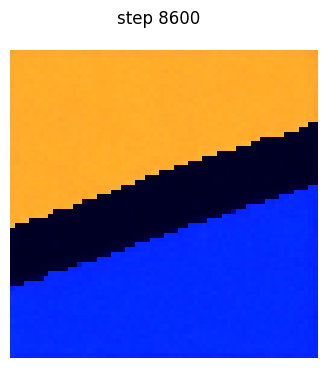

step  8601 | loss 0.0021
step  8602 | loss 0.0024
step  8603 | loss 0.0022
step  8604 | loss 0.0022
step  8605 | loss 0.0024
step  8606 | loss 0.0020
step  8607 | loss 0.0026
step  8608 | loss 0.0026
step  8609 | loss 0.0024
step  8610 | loss 0.0019
step  8611 | loss 0.0028
step  8612 | loss 0.0028
step  8613 | loss 0.0029
step  8614 | loss 0.0023
step  8615 | loss 0.0024
step  8616 | loss 0.0022
step  8617 | loss 0.0034
step  8618 | loss 0.0024
step  8619 | loss 0.0030
step  8620 | loss 0.0024
step  8621 | loss 0.0029
step  8622 | loss 0.0029
step  8623 | loss 0.0025
step  8624 | loss 0.0026
step  8625 | loss 0.0035
step  8626 | loss 0.0024
step  8627 | loss 0.0027
step  8628 | loss 0.0025
step  8629 | loss 0.0022
step  8630 | loss 0.0036
step  8631 | loss 0.0026
step  8632 | loss 0.0032
step  8633 | loss 0.0025
step  8634 | loss 0.0027
step  8635 | loss 0.0027
step  8636 | loss 0.0024
step  8637 | loss 0.0022
step  8638 | loss 0.0022
step  8639 | loss 0.0025
step  8640 | loss 0.0025


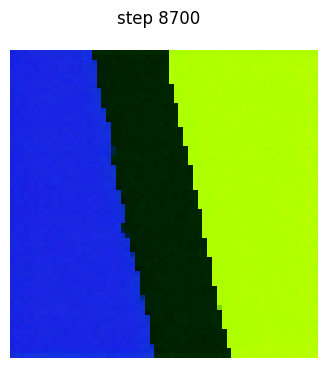

step  8701 | loss 0.0022
step  8702 | loss 0.0021
step  8703 | loss 0.0020
step  8704 | loss 0.0020
step  8705 | loss 0.0022
step  8706 | loss 0.0020
step  8707 | loss 0.0022
step  8708 | loss 0.0024
step  8709 | loss 0.0021
step  8710 | loss 0.0022
step  8711 | loss 0.0023
step  8712 | loss 0.0017
step  8713 | loss 0.0021
step  8714 | loss 0.0023
step  8715 | loss 0.0018
step  8716 | loss 0.0023
step  8717 | loss 0.0020
step  8718 | loss 0.0022
step  8719 | loss 0.0021
step  8720 | loss 0.0019
step  8721 | loss 0.0018
step  8722 | loss 0.0019
step  8723 | loss 0.0022
step  8724 | loss 0.0020
step  8725 | loss 0.0020
step  8726 | loss 0.0023
step  8727 | loss 0.0021
step  8728 | loss 0.0024
step  8729 | loss 0.0019
step  8730 | loss 0.0021
step  8731 | loss 0.0020
step  8732 | loss 0.0021
step  8733 | loss 0.0023
step  8734 | loss 0.0022
step  8735 | loss 0.0020
step  8736 | loss 0.0017
step  8737 | loss 0.0020
step  8738 | loss 0.0021
step  8739 | loss 0.0019
step  8740 | loss 0.0018


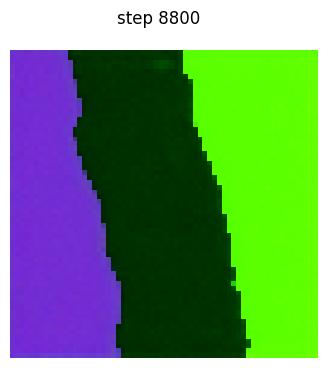

step  8801 | loss 0.0020
step  8802 | loss 0.0017
step  8803 | loss 0.0022
step  8804 | loss 0.0022
step  8805 | loss 0.0020
step  8806 | loss 0.0019
step  8807 | loss 0.0022
step  8808 | loss 0.0019
step  8809 | loss 0.0020
step  8810 | loss 0.0021
step  8811 | loss 0.0024
step  8812 | loss 0.0019
step  8813 | loss 0.0018
step  8814 | loss 0.0020
step  8815 | loss 0.0023
step  8816 | loss 0.0019
step  8817 | loss 0.0019
step  8818 | loss 0.0023
step  8819 | loss 0.0021
step  8820 | loss 0.0020
step  8821 | loss 0.0019
step  8822 | loss 0.0019
step  8823 | loss 0.0026
step  8824 | loss 0.0020
step  8825 | loss 0.0019
step  8826 | loss 0.0019
step  8827 | loss 0.0020
step  8828 | loss 0.0025
step  8829 | loss 0.0022
step  8830 | loss 0.0020
step  8831 | loss 0.0021
step  8832 | loss 0.0019
step  8833 | loss 0.0020
step  8834 | loss 0.0023
step  8835 | loss 0.0023
step  8836 | loss 0.0020
step  8837 | loss 0.0022
step  8838 | loss 0.0017
step  8839 | loss 0.0021
step  8840 | loss 0.0023


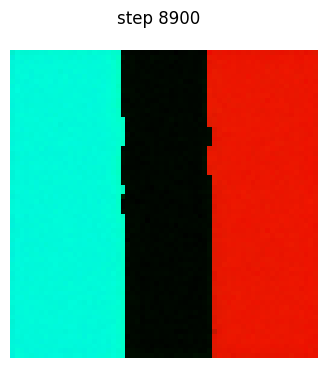

step  8901 | loss 0.0028
step  8902 | loss 0.0025
step  8903 | loss 0.0022
step  8904 | loss 0.0022
step  8905 | loss 0.0020
step  8906 | loss 0.0022
step  8907 | loss 0.0027
step  8908 | loss 0.0025
step  8909 | loss 0.0021
step  8910 | loss 0.0021
step  8911 | loss 0.0021
step  8912 | loss 0.0023
step  8913 | loss 0.0023
step  8914 | loss 0.0025
step  8915 | loss 0.0021
step  8916 | loss 0.0024
step  8917 | loss 0.0023
step  8918 | loss 0.0027
step  8919 | loss 0.0024
step  8920 | loss 0.0026
step  8921 | loss 0.0032
step  8922 | loss 0.0022
step  8923 | loss 0.0025
step  8924 | loss 0.0022
step  8925 | loss 0.0022
step  8926 | loss 0.0024
step  8927 | loss 0.0019
step  8928 | loss 0.0025
step  8929 | loss 0.0020
step  8930 | loss 0.0024
step  8931 | loss 0.0023
step  8932 | loss 0.0028
step  8933 | loss 0.0024
step  8934 | loss 0.0024
step  8935 | loss 0.0025
step  8936 | loss 0.0026
step  8937 | loss 0.0024
step  8938 | loss 0.0022
step  8939 | loss 0.0025
step  8940 | loss 0.0025


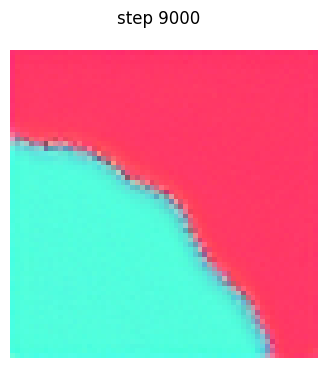

step  9001 | loss 0.0023
step  9002 | loss 0.0018
step  9003 | loss 0.0022
step  9004 | loss 0.0024
step  9005 | loss 0.0019
step  9006 | loss 0.0022
step  9007 | loss 0.0024
step  9008 | loss 0.0025
step  9009 | loss 0.0023
step  9010 | loss 0.0026
step  9011 | loss 0.0024
step  9012 | loss 0.0025
step  9013 | loss 0.0024
step  9014 | loss 0.0022
step  9015 | loss 0.0023
step  9016 | loss 0.0023
step  9017 | loss 0.0022
step  9018 | loss 0.0020
step  9019 | loss 0.0025
step  9020 | loss 0.0027
step  9021 | loss 0.0021
step  9022 | loss 0.0028
step  9023 | loss 0.0021
step  9024 | loss 0.0024
step  9025 | loss 0.0024
step  9026 | loss 0.0024
step  9027 | loss 0.0025
step  9028 | loss 0.0027
step  9029 | loss 0.0024
step  9030 | loss 0.0027
step  9031 | loss 0.0031
step  9032 | loss 0.0021
step  9033 | loss 0.0023
step  9034 | loss 0.0027
step  9035 | loss 0.0027
step  9036 | loss 0.0022
step  9037 | loss 0.0023
step  9038 | loss 0.0024
step  9039 | loss 0.0024
step  9040 | loss 0.0026


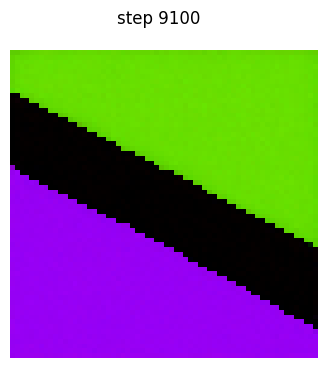

step  9101 | loss 0.0023
step  9102 | loss 0.0027
step  9103 | loss 0.0020
step  9104 | loss 0.0020
step  9105 | loss 0.0025
step  9106 | loss 0.0021
step  9107 | loss 0.0024
step  9108 | loss 0.0021
step  9109 | loss 0.0023
step  9110 | loss 0.0030
step  9111 | loss 0.0026
step  9112 | loss 0.0026
step  9113 | loss 0.0026
step  9114 | loss 0.0023
step  9115 | loss 0.0025
step  9116 | loss 0.0030
step  9117 | loss 0.0021
step  9118 | loss 0.0021
step  9119 | loss 0.0020
step  9120 | loss 0.0025
step  9121 | loss 0.0027
step  9122 | loss 0.0025
step  9123 | loss 0.0023
step  9124 | loss 0.0026
step  9125 | loss 0.0033
step  9126 | loss 0.0024
step  9127 | loss 0.0023
step  9128 | loss 0.0023
step  9129 | loss 0.0028
step  9130 | loss 0.0038
step  9131 | loss 0.0023
step  9132 | loss 0.0022
step  9133 | loss 0.0029
step  9134 | loss 0.0023
step  9135 | loss 0.0024
step  9136 | loss 0.0025
step  9137 | loss 0.0026
step  9138 | loss 0.0029
step  9139 | loss 0.0025
step  9140 | loss 0.0026


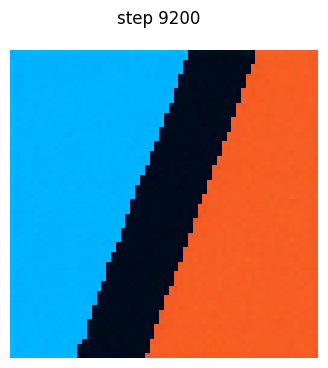

step  9201 | loss 0.0018
step  9202 | loss 0.0019
step  9203 | loss 0.0020
step  9204 | loss 0.0020
step  9205 | loss 0.0017
step  9206 | loss 0.0019
step  9207 | loss 0.0016
step  9208 | loss 0.0021
step  9209 | loss 0.0019
step  9210 | loss 0.0022
step  9211 | loss 0.0020
step  9212 | loss 0.0020
step  9213 | loss 0.0025
step  9214 | loss 0.0025
step  9215 | loss 0.0025
step  9216 | loss 0.0024
step  9217 | loss 0.0026
step  9218 | loss 0.0021
step  9219 | loss 0.0024
step  9220 | loss 0.0038
step  9221 | loss 0.0038
step  9222 | loss 0.0029
step  9223 | loss 0.0024
step  9224 | loss 0.0023
step  9225 | loss 0.0035
step  9226 | loss 0.0033
step  9227 | loss 0.0040
step  9228 | loss 0.0025
step  9229 | loss 0.0024
step  9230 | loss 0.0031
step  9231 | loss 0.0025
step  9232 | loss 0.0024
step  9233 | loss 0.0035
step  9234 | loss 0.0035
step  9235 | loss 0.0023
step  9236 | loss 0.0029
step  9237 | loss 0.0034
step  9238 | loss 0.0022
step  9239 | loss 0.0024
step  9240 | loss 0.0025


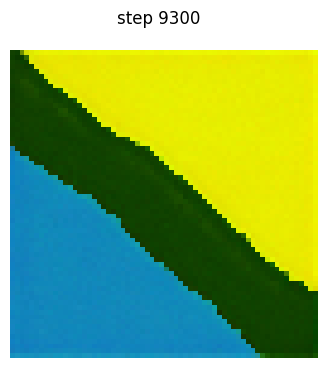

step  9301 | loss 0.0020
step  9302 | loss 0.0021
step  9303 | loss 0.0019
step  9304 | loss 0.0020
step  9305 | loss 0.0020
step  9306 | loss 0.0016
step  9307 | loss 0.0018
step  9308 | loss 0.0019
step  9309 | loss 0.0019
step  9310 | loss 0.0019
step  9311 | loss 0.0019
step  9312 | loss 0.0019
step  9313 | loss 0.0020
step  9314 | loss 0.0019
step  9315 | loss 0.0018
step  9316 | loss 0.0023
step  9317 | loss 0.0019
step  9318 | loss 0.0017
step  9319 | loss 0.0019
step  9320 | loss 0.0019
step  9321 | loss 0.0021
step  9322 | loss 0.0019
step  9323 | loss 0.0020
step  9324 | loss 0.0022
step  9325 | loss 0.0019
step  9326 | loss 0.0021
step  9327 | loss 0.0018
step  9328 | loss 0.0022
step  9329 | loss 0.0017
step  9330 | loss 0.0016
step  9331 | loss 0.0021
step  9332 | loss 0.0019
step  9333 | loss 0.0018
step  9334 | loss 0.0017
step  9335 | loss 0.0018
step  9336 | loss 0.0025
step  9337 | loss 0.0019
step  9338 | loss 0.0020
step  9339 | loss 0.0020
step  9340 | loss 0.0017


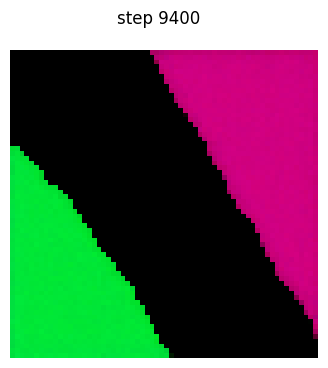

step  9401 | loss 0.0023
step  9402 | loss 0.0026
step  9403 | loss 0.0019
step  9404 | loss 0.0022
step  9405 | loss 0.0019
step  9406 | loss 0.0019
step  9407 | loss 0.0023
step  9408 | loss 0.0023
step  9409 | loss 0.0023
step  9410 | loss 0.0031
step  9411 | loss 0.0024
step  9412 | loss 0.0026
step  9413 | loss 0.0038
step  9414 | loss 0.0026
step  9415 | loss 0.0024
step  9416 | loss 0.0023
step  9417 | loss 0.0025
step  9418 | loss 0.0024
step  9419 | loss 0.0021
step  9420 | loss 0.0022
step  9421 | loss 0.0023
step  9422 | loss 0.0021
step  9423 | loss 0.0022
step  9424 | loss 0.0023
step  9425 | loss 0.0021
step  9426 | loss 0.0024
step  9427 | loss 0.0020
step  9428 | loss 0.0017
step  9429 | loss 0.0019
step  9430 | loss 0.0023
step  9431 | loss 0.0019
step  9432 | loss 0.0025
step  9433 | loss 0.0020
step  9434 | loss 0.0027
step  9435 | loss 0.0023
step  9436 | loss 0.0021
step  9437 | loss 0.0026
step  9438 | loss 0.0023
step  9439 | loss 0.0026
step  9440 | loss 0.0026


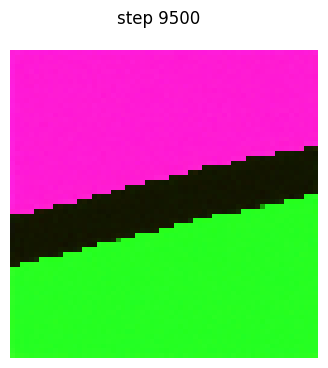

step  9501 | loss 0.0016
step  9502 | loss 0.0017
step  9503 | loss 0.0015
step  9504 | loss 0.0018
step  9505 | loss 0.0019
step  9506 | loss 0.0018
step  9507 | loss 0.0015
step  9508 | loss 0.0019
step  9509 | loss 0.0019
step  9510 | loss 0.0016
step  9511 | loss 0.0019
step  9512 | loss 0.0018
step  9513 | loss 0.0018
step  9514 | loss 0.0016
step  9515 | loss 0.0021
step  9516 | loss 0.0017
step  9517 | loss 0.0018
step  9518 | loss 0.0021
step  9519 | loss 0.0017
step  9520 | loss 0.0019
step  9521 | loss 0.0016
step  9522 | loss 0.0015
step  9523 | loss 0.0018
step  9524 | loss 0.0019
step  9525 | loss 0.0018
step  9526 | loss 0.0019
step  9527 | loss 0.0017
step  9528 | loss 0.0016
step  9529 | loss 0.0019
step  9530 | loss 0.0019
step  9531 | loss 0.0017
step  9532 | loss 0.0028
step  9533 | loss 0.0021
step  9534 | loss 0.0022
step  9535 | loss 0.0025
step  9536 | loss 0.0022
step  9537 | loss 0.0017
step  9538 | loss 0.0021
step  9539 | loss 0.0022
step  9540 | loss 0.0020


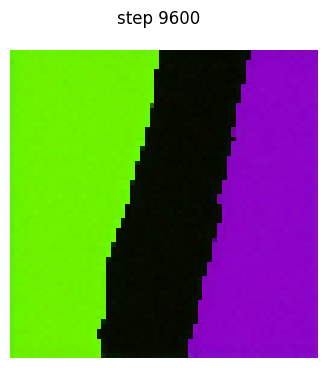

step  9601 | loss 0.0024
step  9602 | loss 0.0021
step  9603 | loss 0.0021
step  9604 | loss 0.0021
step  9605 | loss 0.0018
step  9606 | loss 0.0023
step  9607 | loss 0.0021
step  9608 | loss 0.0022
step  9609 | loss 0.0021
step  9610 | loss 0.0019
step  9611 | loss 0.0024
step  9612 | loss 0.0025
step  9613 | loss 0.0020
step  9614 | loss 0.0023
step  9615 | loss 0.0017
step  9616 | loss 0.0018
step  9617 | loss 0.0022
step  9618 | loss 0.0023
step  9619 | loss 0.0021
step  9620 | loss 0.0021
step  9621 | loss 0.0022
step  9622 | loss 0.0019
step  9623 | loss 0.0030
step  9624 | loss 0.0019
step  9625 | loss 0.0017
step  9626 | loss 0.0026
step  9627 | loss 0.0020
step  9628 | loss 0.0021
step  9629 | loss 0.0018
step  9630 | loss 0.0019
step  9631 | loss 0.0018
step  9632 | loss 0.0020
step  9633 | loss 0.0025
step  9634 | loss 0.0021
step  9635 | loss 0.0021
step  9636 | loss 0.0020
step  9637 | loss 0.0018
step  9638 | loss 0.0020
step  9639 | loss 0.0017
step  9640 | loss 0.0019


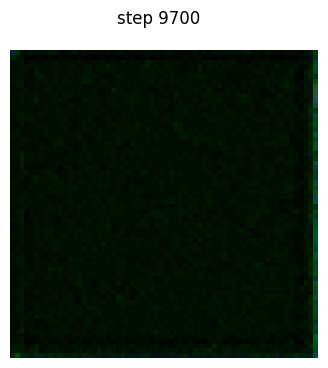

step  9701 | loss 0.0020
step  9702 | loss 0.0018
step  9703 | loss 0.0019
step  9704 | loss 0.0019
step  9705 | loss 0.0020
step  9706 | loss 0.0017
step  9707 | loss 0.0020
step  9708 | loss 0.0018
step  9709 | loss 0.0017
step  9710 | loss 0.0018
step  9711 | loss 0.0019
step  9712 | loss 0.0020
step  9713 | loss 0.0018
step  9714 | loss 0.0016
step  9715 | loss 0.0016
step  9716 | loss 0.0016
step  9717 | loss 0.0018
step  9718 | loss 0.0019
step  9719 | loss 0.0021
step  9720 | loss 0.0017
step  9721 | loss 0.0019
step  9722 | loss 0.0015
step  9723 | loss 0.0017
step  9724 | loss 0.0016
step  9725 | loss 0.0020
step  9726 | loss 0.0015
step  9727 | loss 0.0016
step  9728 | loss 0.0016
step  9729 | loss 0.0018
step  9730 | loss 0.0016
step  9731 | loss 0.0015
step  9732 | loss 0.0019
step  9733 | loss 0.0019
step  9734 | loss 0.0015
step  9735 | loss 0.0017
step  9736 | loss 0.0017
step  9737 | loss 0.0023
step  9738 | loss 0.0018
step  9739 | loss 0.0017
step  9740 | loss 0.0019


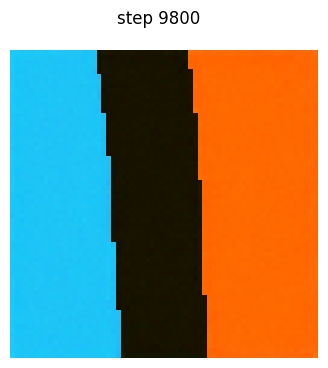

step  9801 | loss 0.0025
step  9802 | loss 0.0023
step  9803 | loss 0.0024
step  9804 | loss 0.0022
step  9805 | loss 0.0023
step  9806 | loss 0.0020
step  9807 | loss 0.0022
step  9808 | loss 0.0026
step  9809 | loss 0.0021
step  9810 | loss 0.0020
step  9811 | loss 0.0019
step  9812 | loss 0.0018
step  9813 | loss 0.0018
step  9814 | loss 0.0019
step  9815 | loss 0.0022
step  9816 | loss 0.0018
step  9817 | loss 0.0017
step  9818 | loss 0.0022
step  9819 | loss 0.0022
step  9820 | loss 0.0018
step  9821 | loss 0.0019
step  9822 | loss 0.0020
step  9823 | loss 0.0019
step  9824 | loss 0.0019
step  9825 | loss 0.0022
step  9826 | loss 0.0019
step  9827 | loss 0.0025
step  9828 | loss 0.0018
step  9829 | loss 0.0021
step  9830 | loss 0.0022
step  9831 | loss 0.0020
step  9832 | loss 0.0018
step  9833 | loss 0.0018
step  9834 | loss 0.0021


KeyboardInterrupt: 

In [ ]:
# training loop:
num_steps = 10000
batch_size = 512
minibatch_size = 128
loss_history = []

fixed_noise = torch.randn(1, 3, 64, 64, device=device)
print_loss_every = 1
preview_every = 100

for step in range(num_steps):
    data = make_toy_batch(batch_size=batch_size, x_dim=64, y_dim=64)
    loss = train_step(data, minibatch_size, unet, ddpm_model)
    loss_history.append(loss)

    if step % print_loss_every == 0:
        print(f"step {step:5d} | loss {loss:.4f}")

    if step % preview_every == 0:
        unet.eval()
        with torch.no_grad():
            samples = sample(unet, ddpm_model, (1, 3, 64, 64))
        show_images(samples, title=f"step {step}")
        unet.train()

In [ ]:
show_images(samples, title="Generated samples")

In [ ]:
samples = sample(unet, ddpm_model, (1, 3, 64, 64))